# EDA — CICDDoS2019 Dataset (Processed Windows)
**PAD-ONAP Phase AI / M2 — Exploratory Data Analysis**

Dataset: 17 entropy/rate features, 100-flow sliding windows (~5s each)

Sections:
1. Dataset overview & class distribution
2. Feature statistics per class
3. Feature distributions (violin + box)
4. Correlation heatmap
5. Train vs Test distribution shift
6. BENIGN analysis (raw 646 windows)
7. Feature separability (PCA + t-SNE)
8. Per-feature attack discriminability

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import pickle, json, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_style('whitegrid')

DATA_DIR = Path('../data/processed_v2')
OUT_DIR  = Path('../notebooks/eda_figures')
OUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = {
    0: 'Normal', 1: 'UDP_Flood', 2: 'SYN_Flood',
    3: 'HTTP_Flood', 4: 'ICMP_Flood', 5: 'Amplification', 6: 'Slow_rate'
}
FEATURE_NAMES = [
    'pkt_rate', 'byte_rate', 'src_ip_entropy', 'dst_ip_entropy',
    'src_port_entropy', 'dst_port_entropy', 'proto_dist_tcp',
    'proto_dist_udp', 'proto_dist_icmp', 'syn_ratio', 'fin_ratio',
    'avg_pkt_size', 'pkt_size_std', 'new_flows_rate',
    'flow_duration_mean', 'inter_arrival_mean', 'inter_arrival_std'
]
PALETTE = {
    0: '#4CAF50', 1: '#F44336', 2: '#2196F3',
    3: '#FF9800', 4: '#9C27B0', 5: '#00BCD4', 6: '#795548'
}

# Load data
X_train = np.load(DATA_DIR / 'X_train.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')
X_benign_raw = np.load(DATA_DIR / 'X_benign_raw.npy')

X_all = np.vstack([X_train, X_test])
y_all = np.hstack([y_train, y_test])

df = pd.DataFrame(X_all, columns=FEATURE_NAMES)
df['class_id']   = y_all
df['class_name'] = df['class_id'].map(CLASS_NAMES)
df['split']      = ['train'] * len(X_train) + ['test'] * len(X_test)

print(f'Total windows : {len(df):,}')
print(f'Train         : {len(X_train):,}')
print(f'Test          : {len(X_test):,}')
print(f'Features      : {len(FEATURE_NAMES)}')
print(f'Classes       : {df["class_name"].nunique()}')
print(f'BENIGN raw    : {len(X_benign_raw):,} unique windows')

Total windows : 35,928
Train         : 28,742
Test          : 7,186
Features      : 17
Classes       : 5
BENIGN raw    : 646 unique windows


## 1. Class Distribution

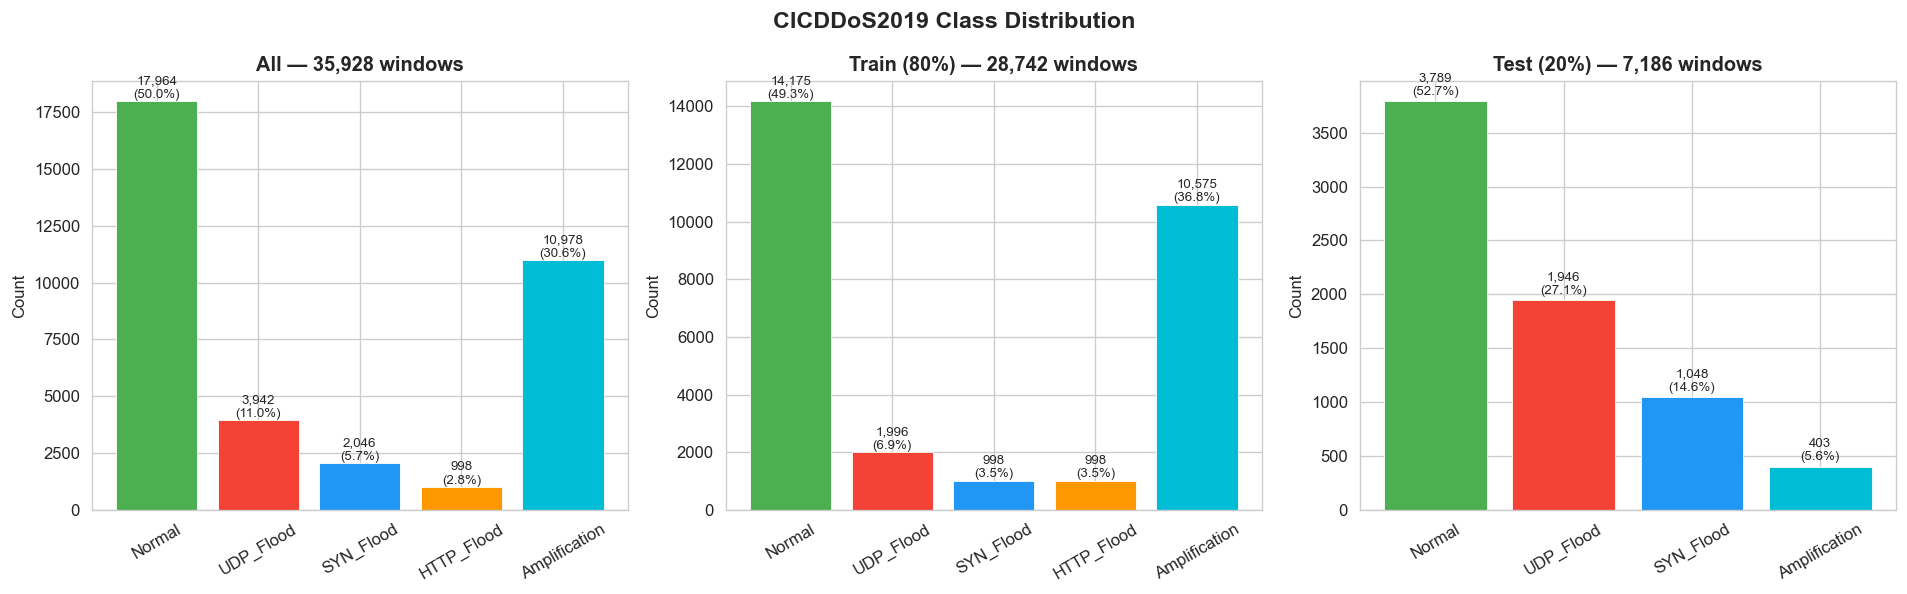

,All,All%,Train,Train%,Test,Test%
Class,,,,,,
Normal,17964,50.0%,14175,49.3%,3789,52.7%
UDP_Flood,3942,11.0%,1996,6.9%,1946,27.1%
SYN_Flood,2046,5.7%,998,3.5%,1048,14.6%
HTTP_Flood,998,2.8%,998,3.5%,0,0.0%
Amplification,10978,30.6%,10575,36.8%,403,5.6%


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = [
    ('All', y_all),
    ('Train (80%)', y_train),
    ('Test (20%)', y_test)
]

for ax, (title, y) in zip(axes, datasets):
    unique, counts = np.unique(y, return_counts=True)
    names  = [CLASS_NAMES[u] for u in unique]
    colors = [PALETTE[u] for u in unique]
    bars = ax.bar(names, counts, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{title} — {len(y):,} windows', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{cnt:,}\n({cnt/len(y)*100:.1f}%)',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('CICDDoS2019 Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '01_class_distribution.png', bbox_inches='tight')
plt.show()

# Table
rows = []
for cls_id in sorted(np.unique(y_all)):
    n_all   = (y_all   == cls_id).sum()
    n_train = (y_train == cls_id).sum()
    n_test  = (y_test  == cls_id).sum()
    rows.append({'Class': CLASS_NAMES[cls_id],
                 'All': n_all, 'All%': f'{n_all/len(y_all)*100:.1f}%',
                 'Train': n_train, 'Train%': f'{n_train/len(y_train)*100:.1f}%',
                 'Test': n_test, 'Test%': f'{n_test/len(y_test)*100:.1f}%'})
pd.DataFrame(rows).set_index('Class')

## 2. Feature Statistics per Class

In [3]:
stats_rows = []
for cls_id in sorted(df['class_id'].unique()):
    subset = df[df['class_id'] == cls_id][FEATURE_NAMES]
    row = {'Class': CLASS_NAMES[cls_id], 'N': len(subset)}
    for feat in FEATURE_NAMES:
        row[f'{feat}_mean'] = subset[feat].mean()
        row[f'{feat}_std']  = subset[feat].std()
    stats_rows.append(row)

stats_df = pd.DataFrame(stats_rows).set_index('Class')

# Show mean table for key features
key_feats = ['pkt_rate', 'byte_rate', 'src_port_entropy', 'dst_port_entropy',
             'proto_dist_tcp', 'proto_dist_udp', 'syn_ratio', 'avg_pkt_size']
mean_cols = [f'{f}_mean' for f in key_feats]
display_df = stats_df[['N'] + mean_cols].copy()
display_df.columns = ['N'] + key_feats
display_df.round(4)

,N,pkt_rate,byte_rate,src_port_entropy,dst_port_entropy,proto_dist_tcp,proto_dist_udp,syn_ratio,avg_pkt_size
Class,,,,,,,,,
Normal,17964,-0.5152,-0.3560,-0.1125,-0.9896,0.6333,-0.6427,-0.0154,-0.5583
UDP_Flood,3942,-0.5151,-0.3559,1.3641,0.9625,-0.2814,0.2953,0.1238,-0.0049
SYN_Flood,2046,-0.5153,-0.3560,1.4074,0.9634,1.7172,-1.6747,-0.0600,-0.7103
HTTP_Flood,998,-0.5152,-0.3560,1.1018,0.9632,1.0309,-0.9982,-0.0546,-0.4473
Amplification,10978,0.8922,0.5918,-0.3710,0.9630,-1.1067,1.1088,-0.0064,0.8377


## 3. Feature Distributions — Violin Plots

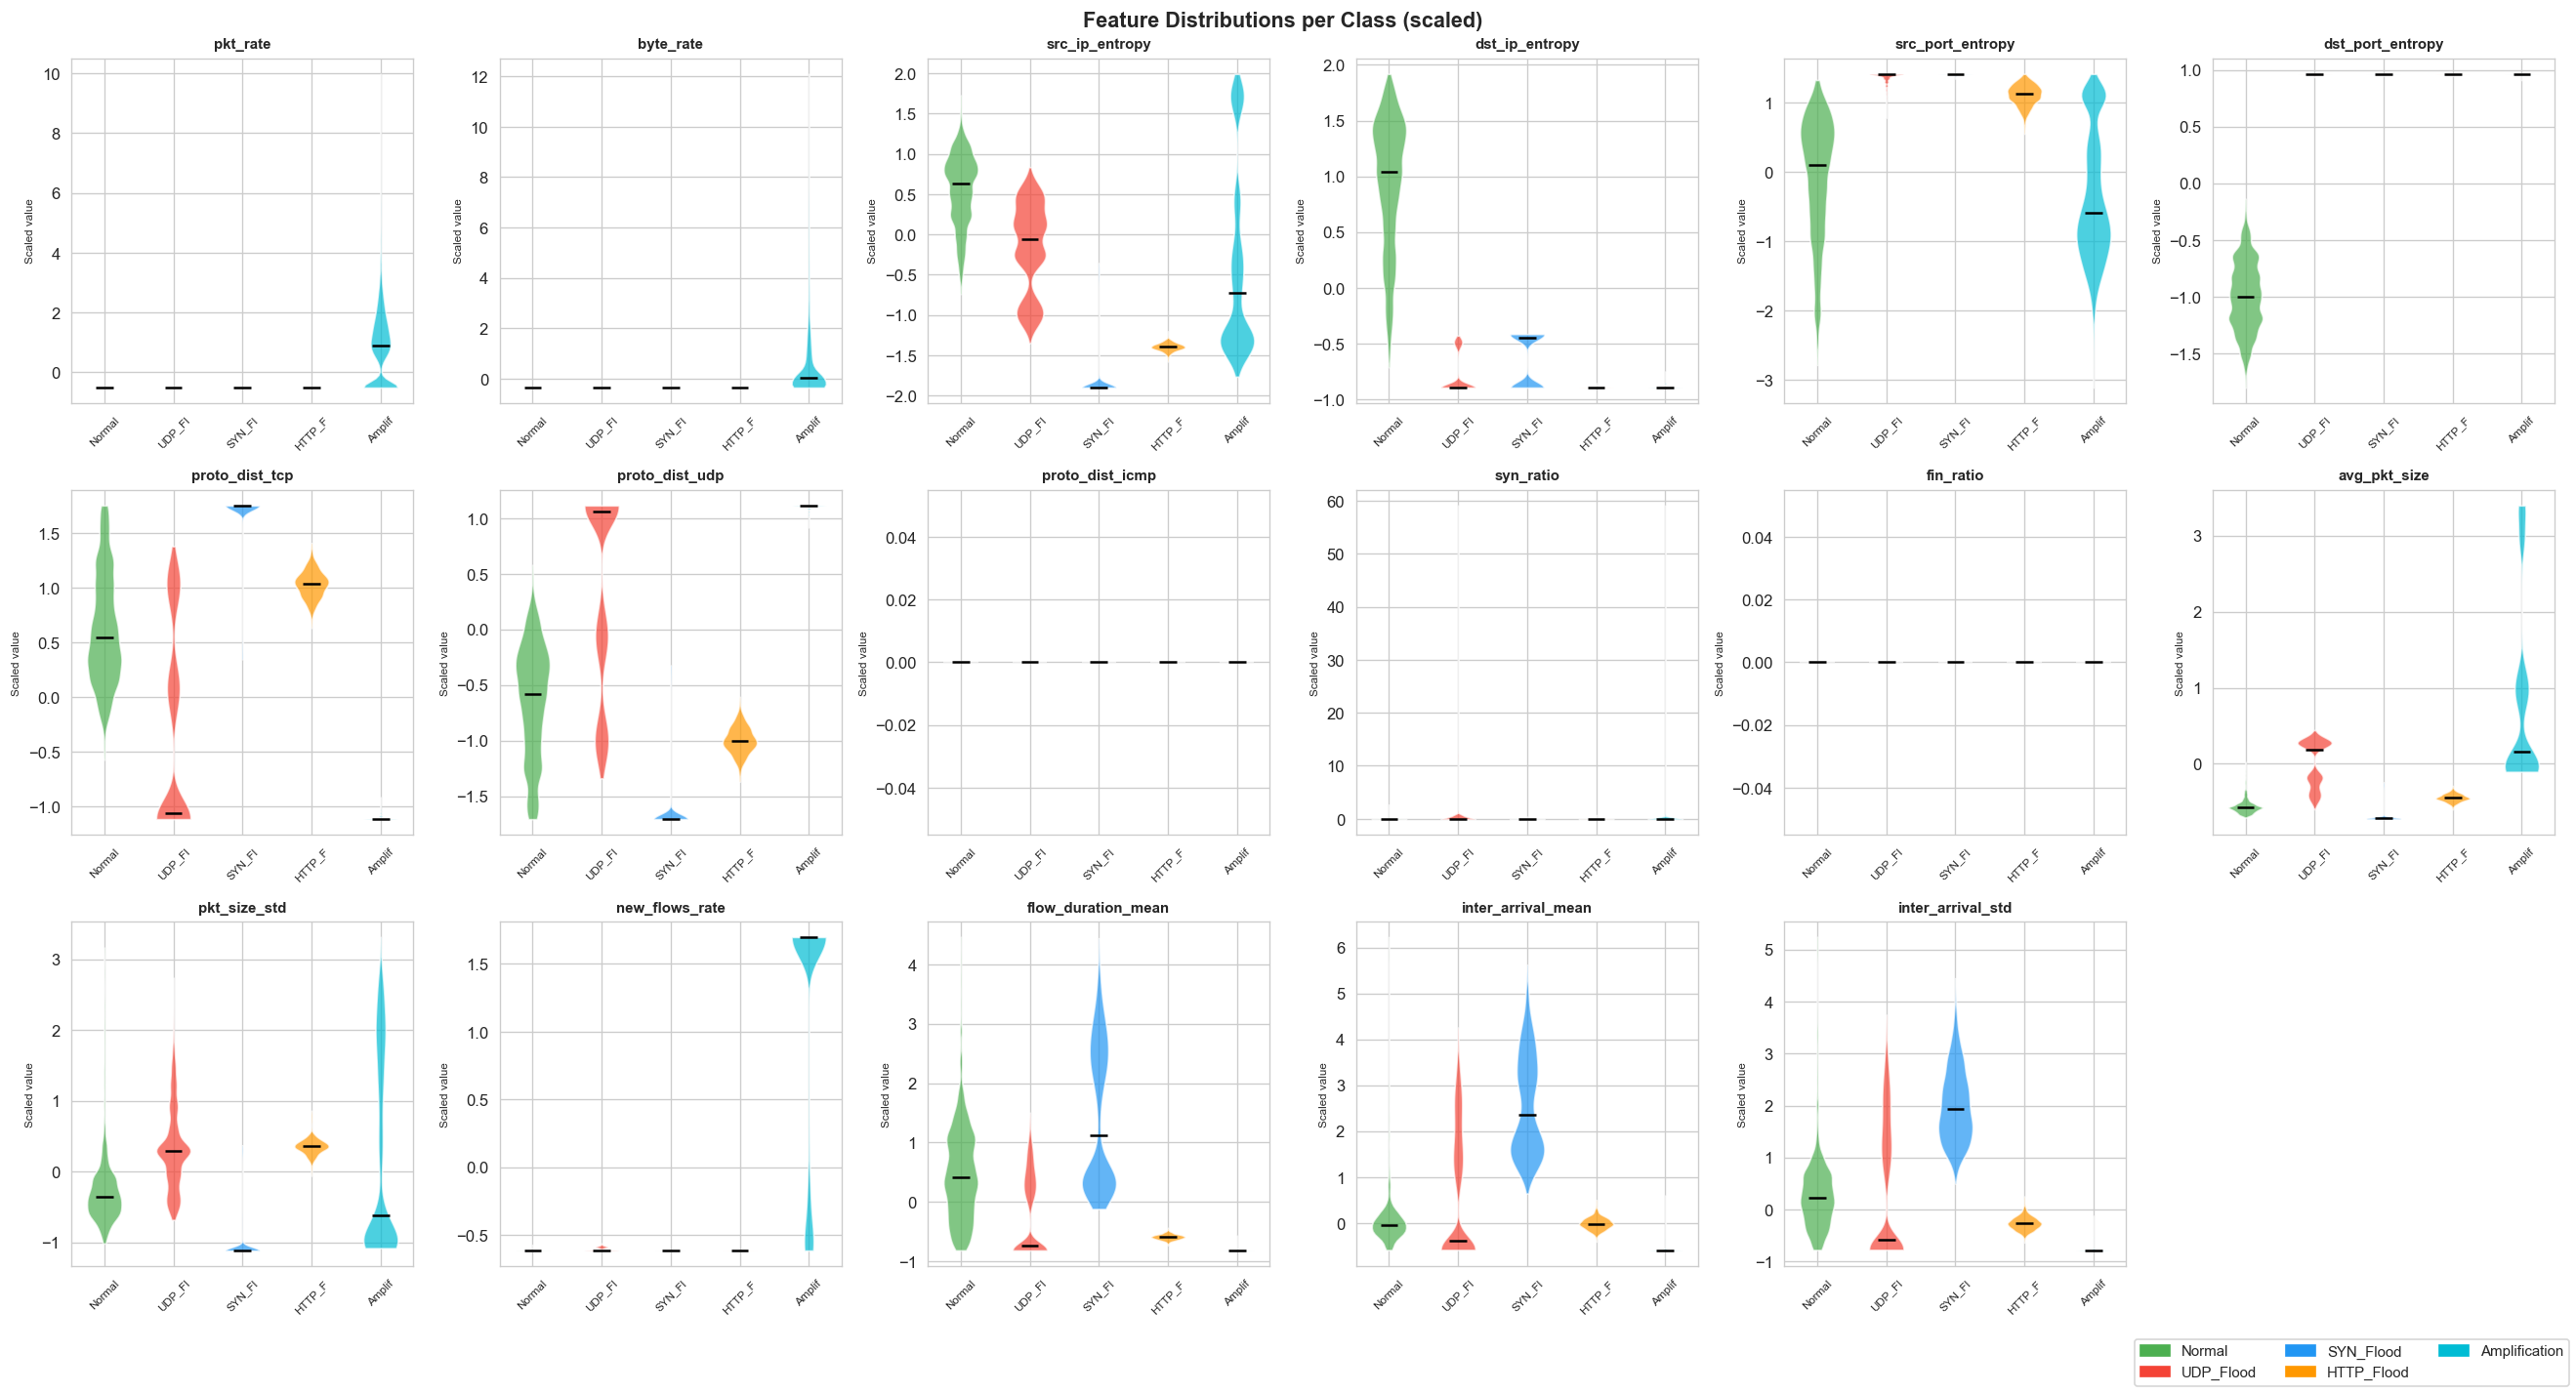

In [4]:
fig, axes = plt.subplots(3, 6, figsize=(22, 12))
axes = axes.flatten()

class_order = sorted(df['class_id'].unique())
class_labels = [CLASS_NAMES[c] for c in class_order]
colors = [PALETTE[c] for c in class_order]

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    data_by_class = [df[df['class_id'] == c][feat].values for c in class_order]
    
    parts = ax.violinplot(data_by_class, positions=range(len(class_order)),
                          showmedians=True, showextrema=False)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)
    
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(class_order)))
    ax.set_xticklabels([CLASS_NAMES[c][:6] for c in class_order],
                       rotation=45, fontsize=7)
    ax.set_ylabel('Scaled value', fontsize=7)

# Hide unused subplot
for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

patches = [mpatches.Patch(color=PALETTE[c], label=CLASS_NAMES[c]) for c in class_order]
fig.legend(handles=patches, loc='lower right', ncol=3, fontsize=9)
plt.suptitle('Feature Distributions per Class (scaled)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUT_DIR / '02_violin_distributions.png', bbox_inches='tight')
plt.show()

## 4. Correlation Heatmap

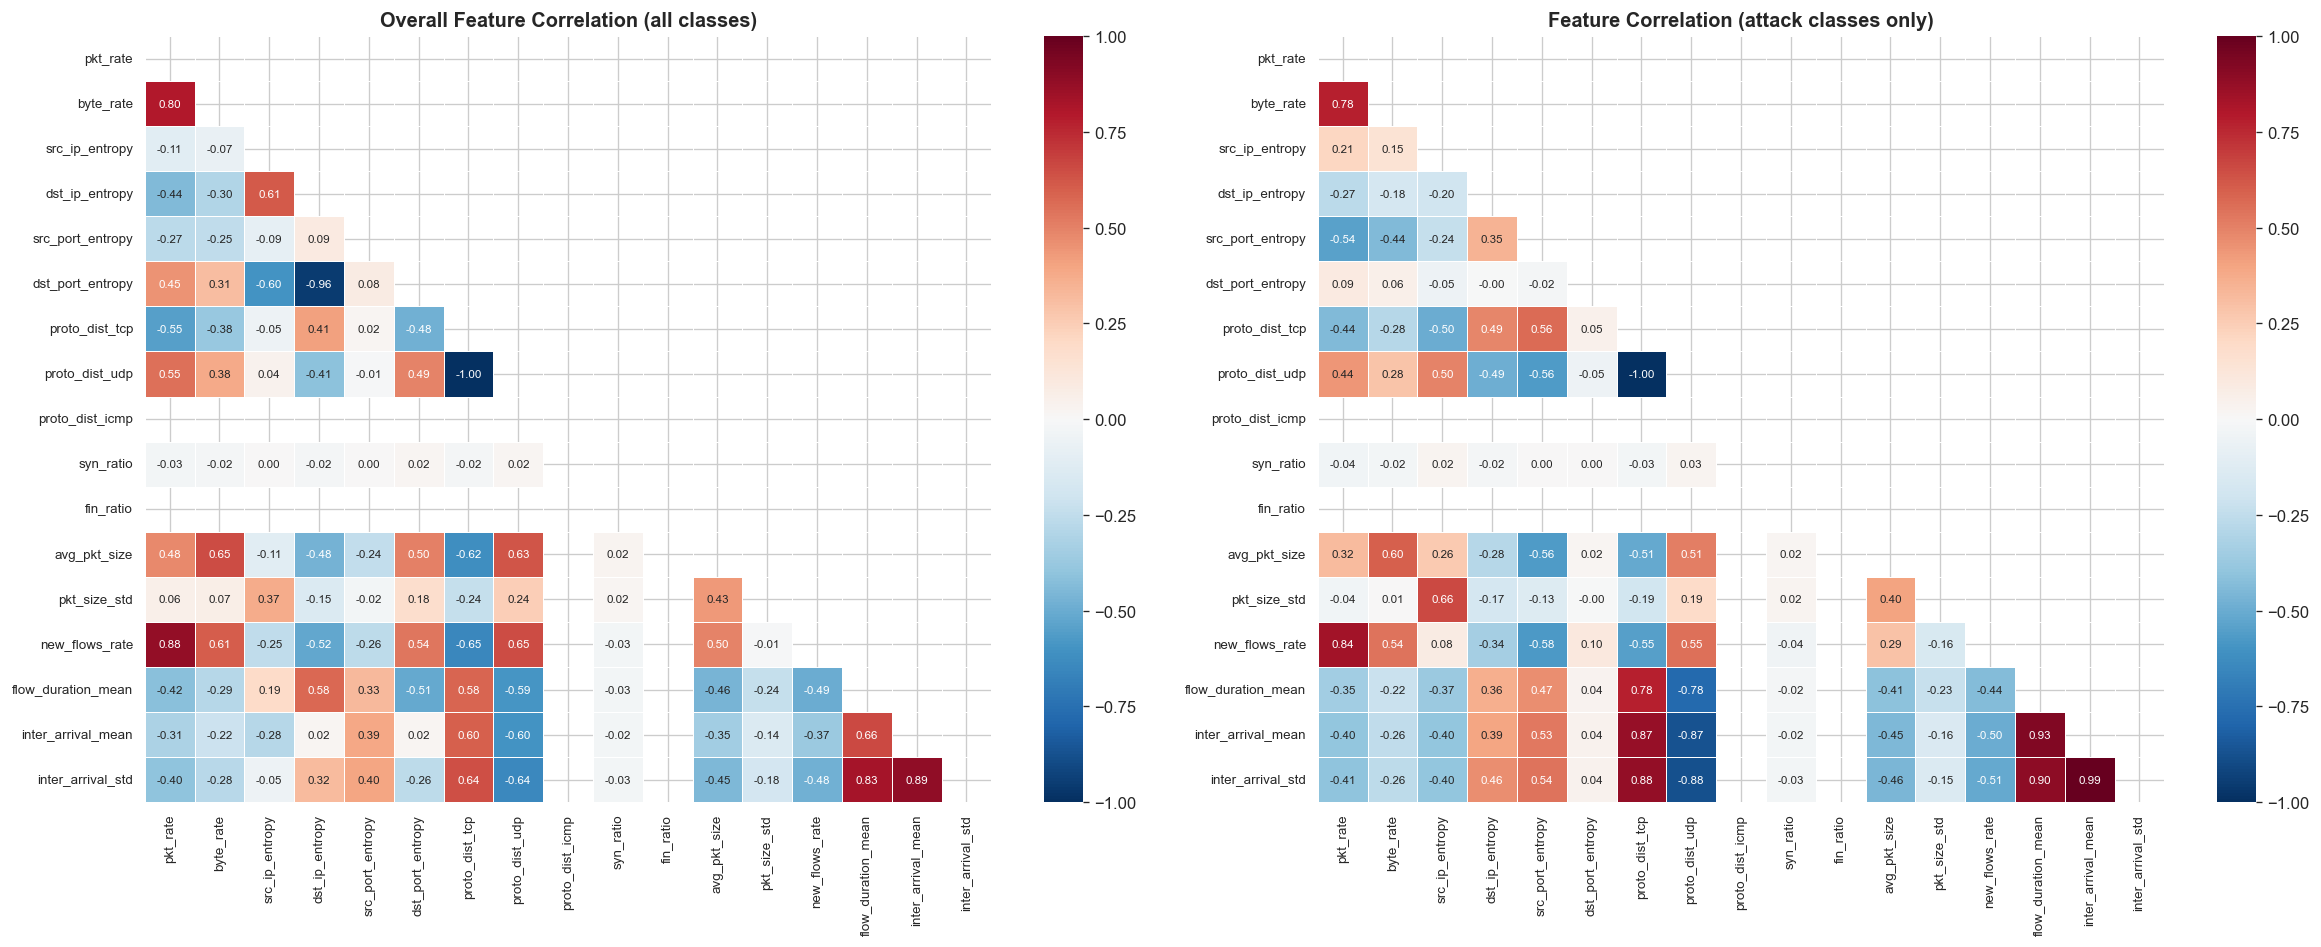


High correlations |r| > 0.8:
  pkt_rate             ↔ byte_rate             r=+0.8039
  pkt_rate             ↔ new_flows_rate        r=+0.8782
  dst_ip_entropy       ↔ dst_port_entropy      r=-0.9554
  proto_dist_tcp       ↔ proto_dist_udp        r=-0.9992
  flow_duration_mean   ↔ inter_arrival_std     r=+0.8333
  inter_arrival_mean   ↔ inter_arrival_std     r=+0.8868


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Overall correlation
corr = df[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 7}, linewidths=0.3)
axes[0].set_title('Overall Feature Correlation (all classes)', fontweight='bold')
axes[0].tick_params(axis='both', labelsize=8)

# Attack-only correlation
df_attack = df[df['class_id'] != 0]
corr_attack = df_attack[FEATURE_NAMES].corr()
sns.heatmap(corr_attack, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[1],
            annot_kws={'size': 7}, linewidths=0.3)
axes[1].set_title('Feature Correlation (attack classes only)', fontweight='bold')
axes[1].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / '03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print high correlations (|r| > 0.8)
print('\nHigh correlations |r| > 0.8:')
for i in range(len(FEATURE_NAMES)):
    for j in range(i+1, len(FEATURE_NAMES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            print(f'  {FEATURE_NAMES[i]:20s} ↔ {FEATURE_NAMES[j]:20s}  r={r:+.4f}')

## 5. Train vs Test Distribution Shift

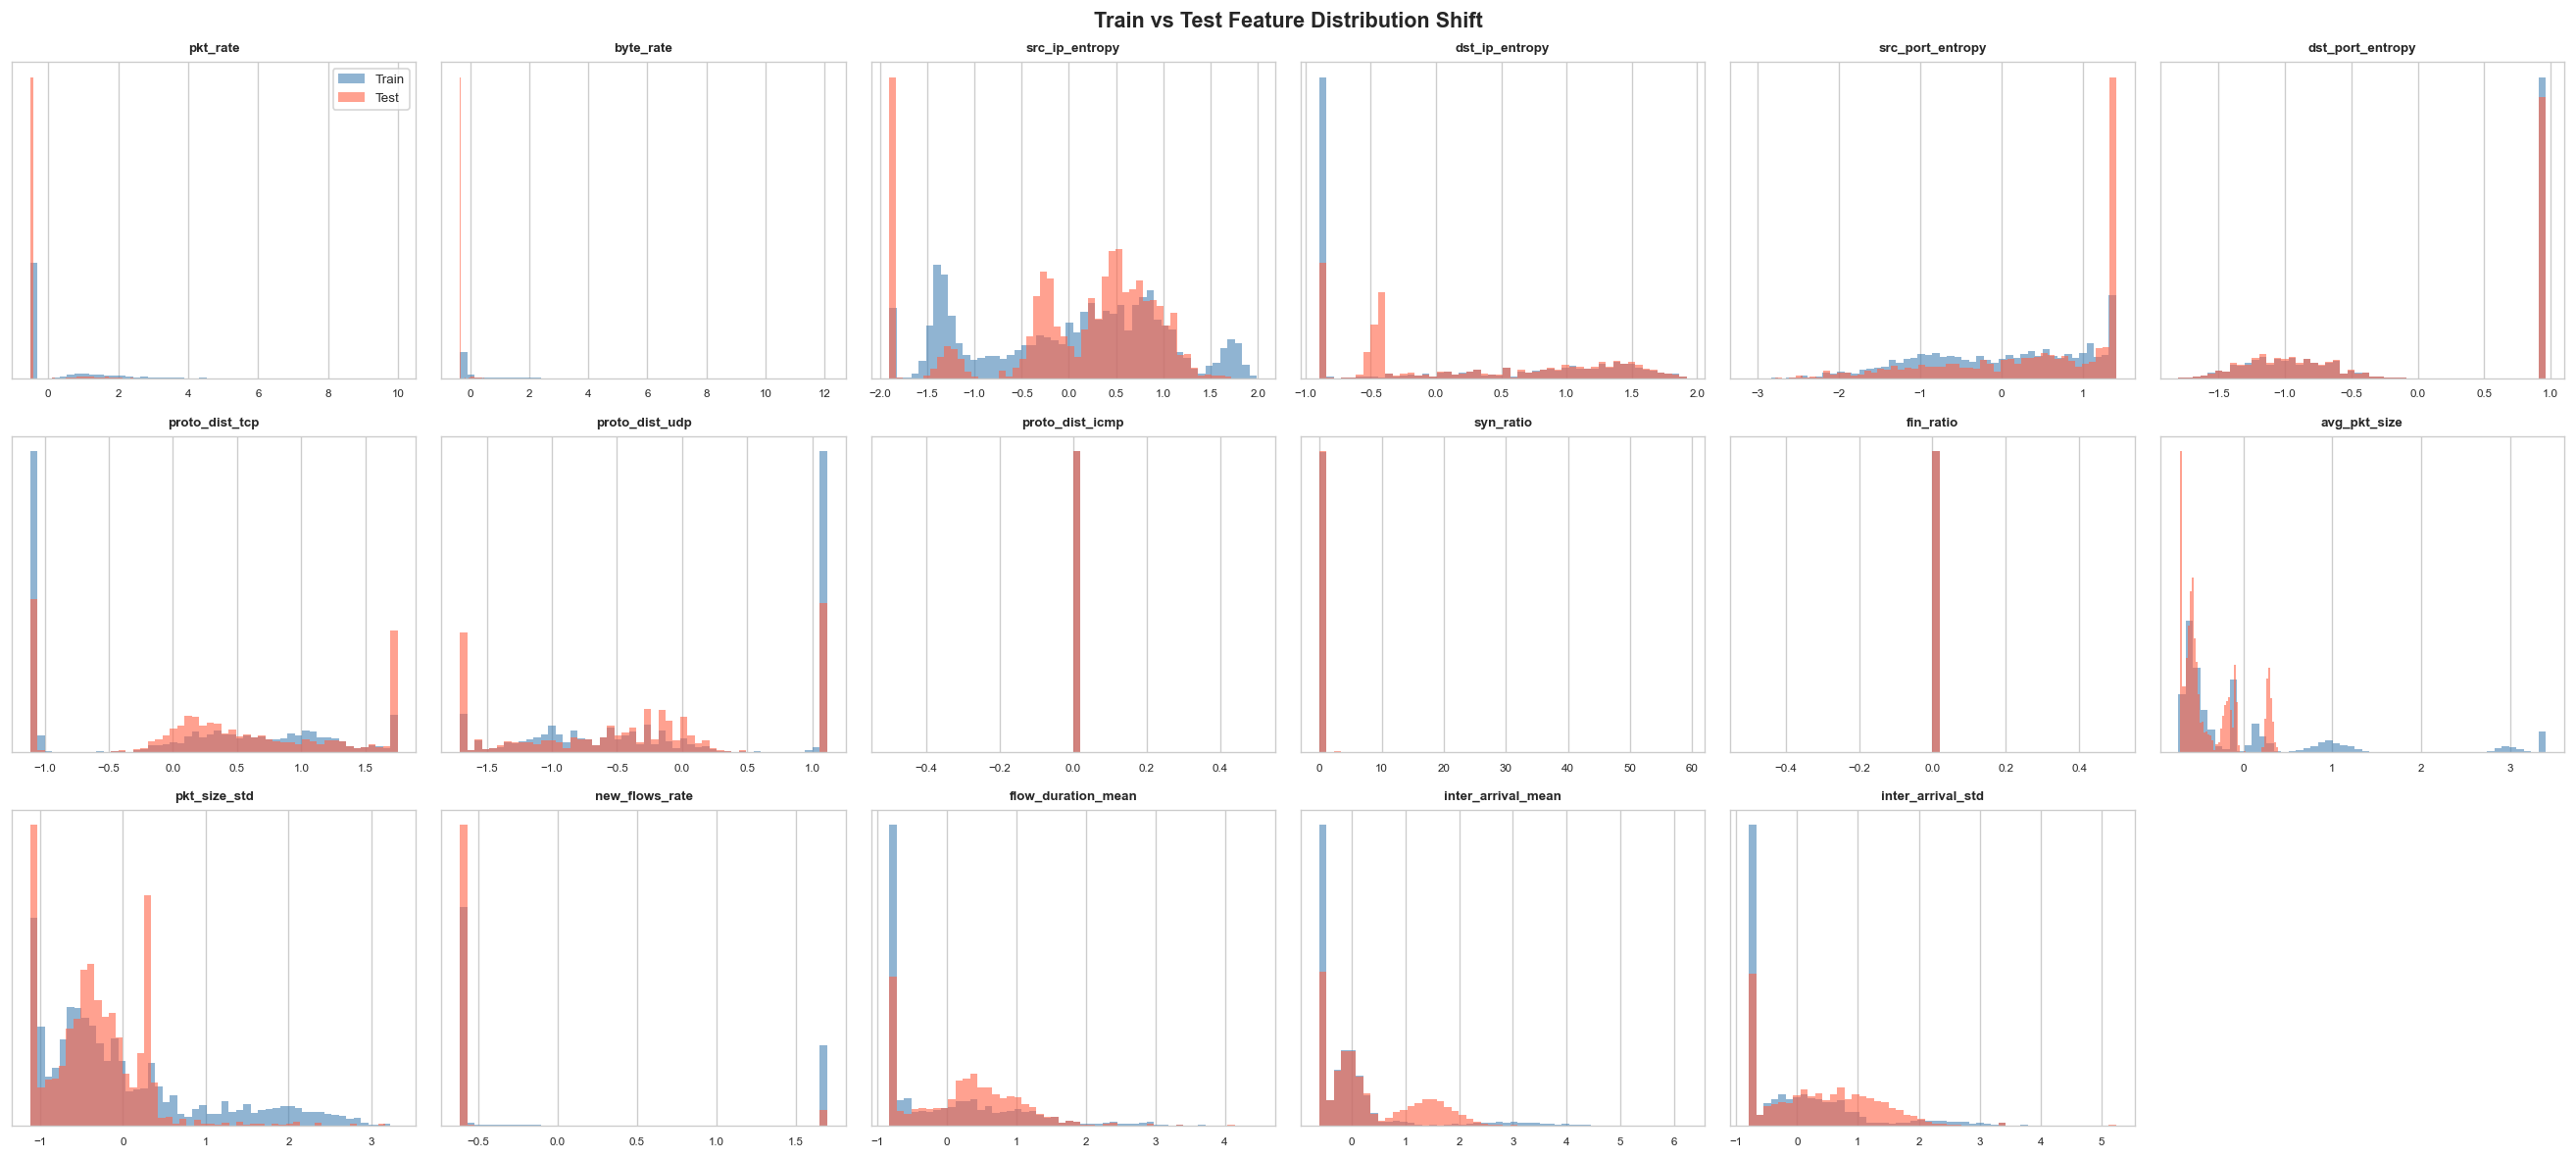

In [6]:
fig, axes = plt.subplots(3, 6, figsize=(22, 10))
axes = axes.flatten()

df_train = df[df['split'] == 'train']
df_test  = df[df['split'] == 'test']

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(df_train[feat], bins=50, alpha=0.6, color='steelblue',
            density=True, label='Train', linewidth=0)
    ax.hist(df_test[feat],  bins=50, alpha=0.6, color='tomato',
            density=True, label='Test', linewidth=0)
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_yticks([])

for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8)
plt.suptitle('Train vs Test Feature Distribution Shift', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '04_train_test_shift.png', bbox_inches='tight')
plt.show()

## 6. BENIGN Deep Analysis

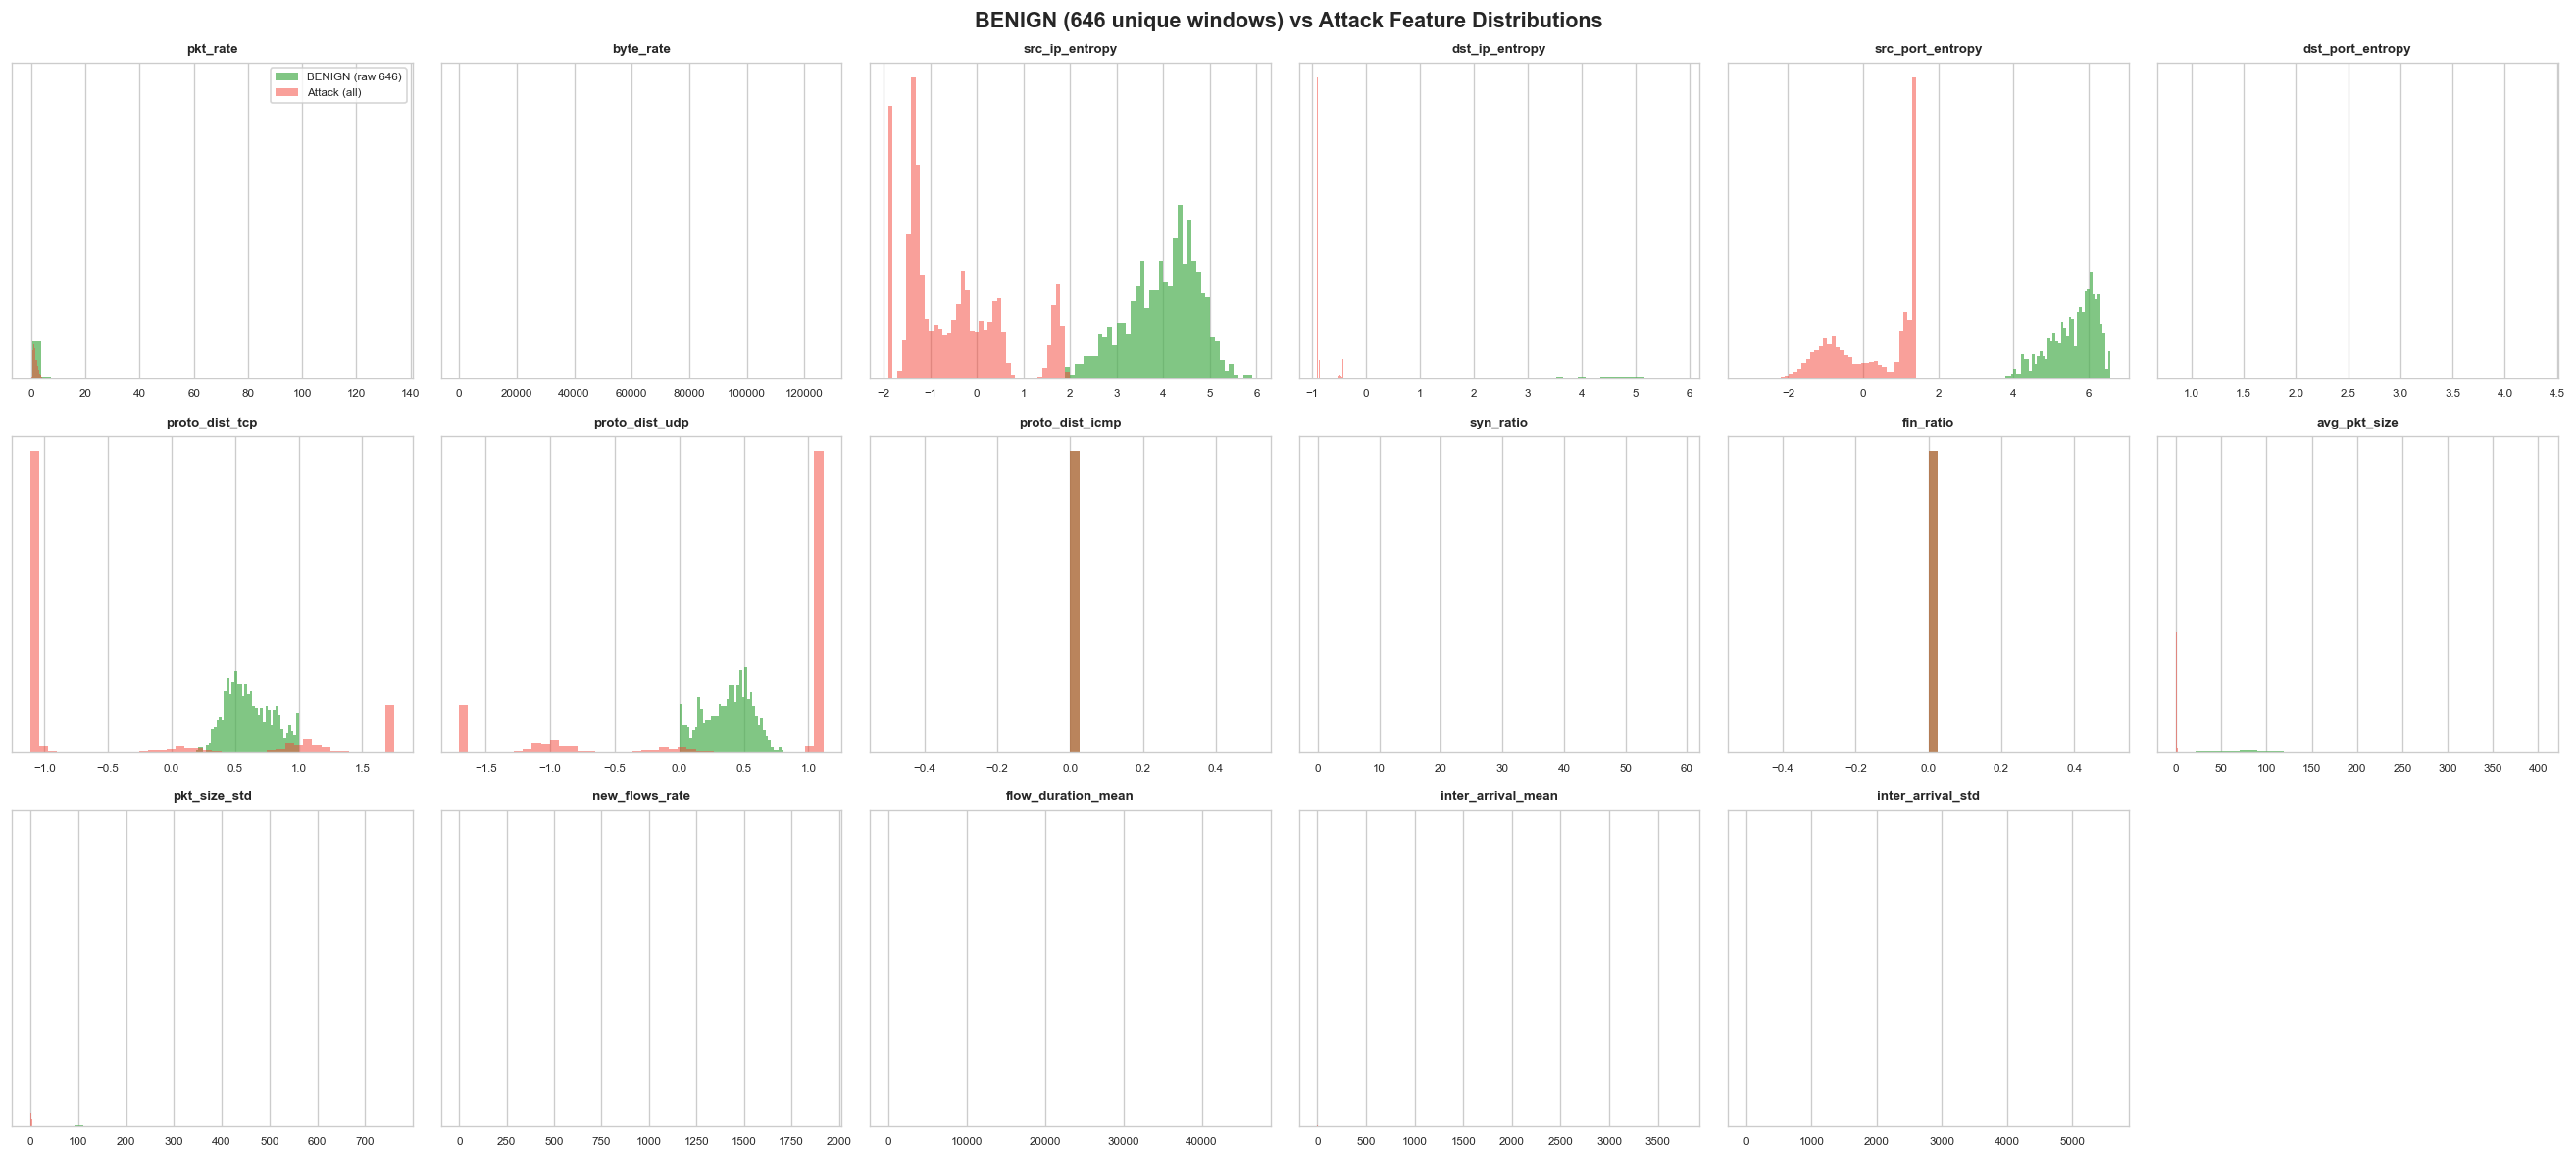

Feature Mean: BENIGN vs Attack
Feature                        BENIGN      Attack     Ratio
------------------------------------------------------------
pkt_rate                       3.7678      0.3449      0.09x
byte_rate                   2916.1521      0.2232      0.00x
src_ip_entropy                 3.9927     -0.5536     -0.14x
dst_ip_entropy                 3.7684     -0.8438     -0.22x
src_port_entropy               5.6050      0.2941      0.05x
dst_port_entropy               2.5536      0.9629      0.38x
proto_dist_tcp                 0.6119     -0.4852     -0.79x
proto_dist_udp                 0.3751      0.4962      1.32x
proto_dist_icmp                0.0000      0.0000      0.00x
syn_ratio                      0.0004      0.0134     31.92x
fin_ratio                      0.0000      0.0000      0.00x
avg_pkt_size                  90.7196      0.4051      0.00x
pkt_size_std                 153.9248      0.1170      0.00x
new_flows_rate                34.7611      0.4197      

In [7]:
df_benign = pd.DataFrame(X_benign_raw, columns=FEATURE_NAMES)
df_attack_only = df[df['class_id'] != 0][FEATURE_NAMES]

fig, axes = plt.subplots(3, 6, figsize=(22, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(df_benign[feat], bins=40, alpha=0.7, color='#4CAF50',
            density=True, label='BENIGN (raw 646)', linewidth=0)
    ax.hist(df_attack_only[feat], bins=40, alpha=0.5, color='#F44336',
            density=True, label='Attack (all)', linewidth=0)
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_yticks([])

for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=7)
plt.suptitle('BENIGN (646 unique windows) vs Attack Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '05_benign_vs_attack.png', bbox_inches='tight')
plt.show()

# Stats comparison
print('Feature Mean: BENIGN vs Attack')
print(f'{"Feature":25s}  {"BENIGN":>10s}  {"Attack":>10s}  {"Ratio":>8s}')
print('-' * 60)
for feat in FEATURE_NAMES:
    b_mean = df_benign[feat].mean()
    a_mean = df_attack_only[feat].mean()
    ratio  = a_mean / (b_mean + 1e-9)
    print(f'{feat:25s}  {b_mean:10.4f}  {a_mean:10.4f}  {ratio:8.2f}x')

## 7. PCA + t-SNE Visualization

Running t-SNE (may take ~30s)...


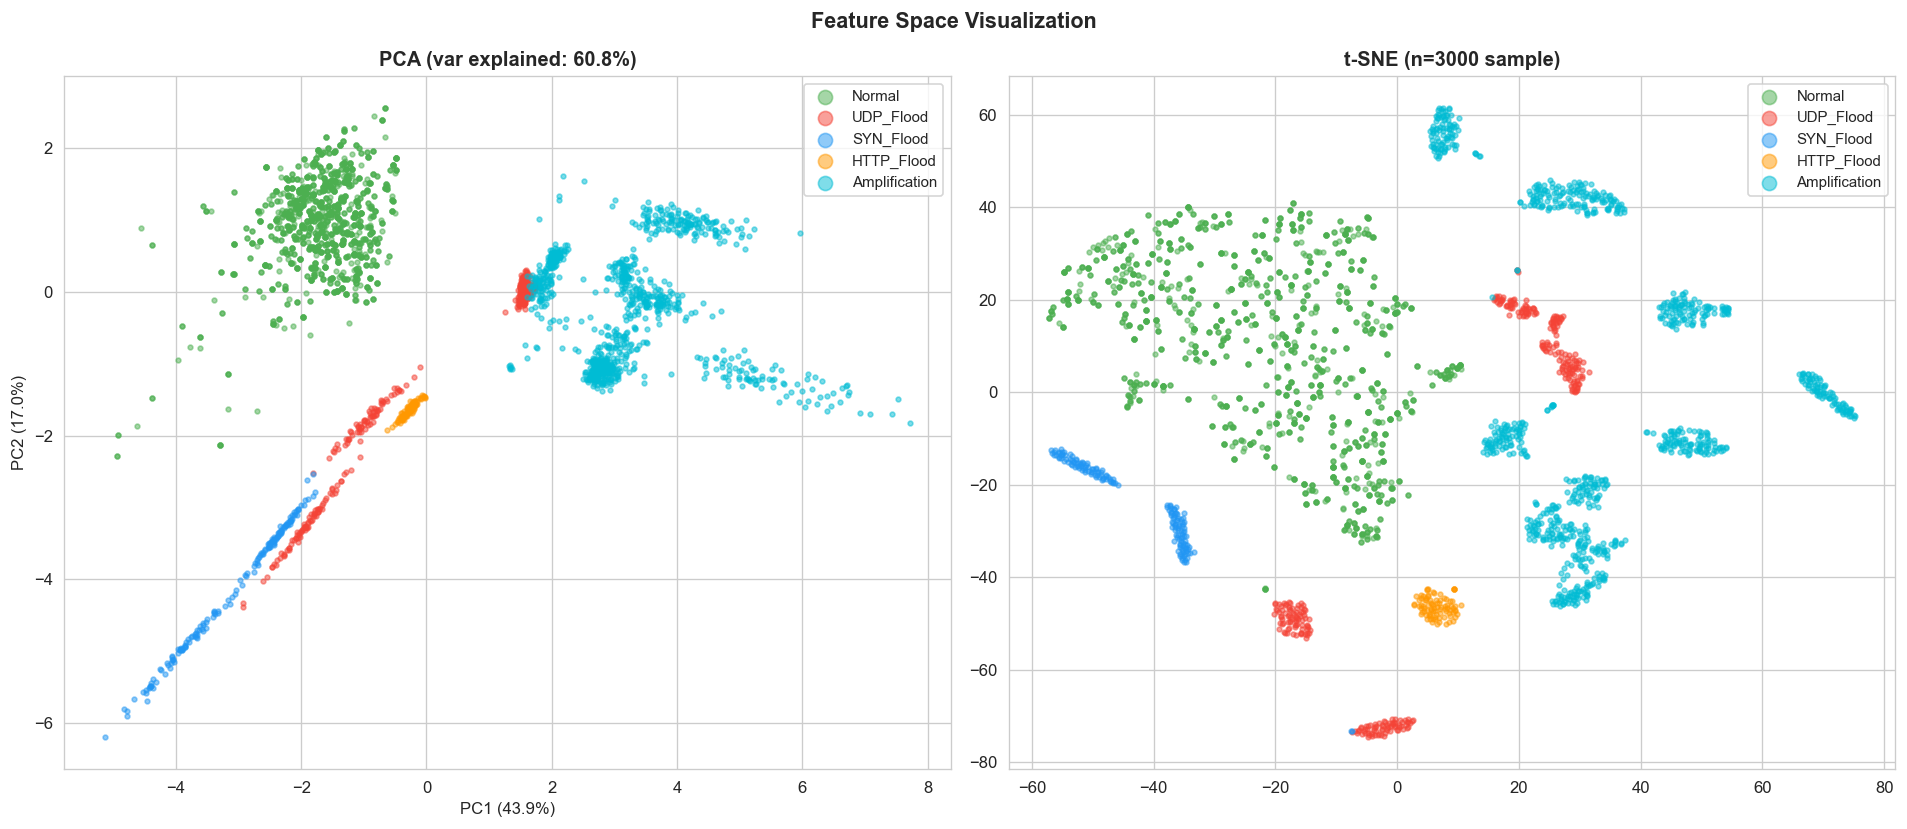

In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sklearn

# Sample for speed
np.random.seed(42)
n_sample = min(3000, len(df))
idx = np.random.choice(len(df), n_sample, replace=False)
X_sample = df.iloc[idx][FEATURE_NAMES].values
y_sample = df.iloc[idx]['class_id'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)
for cls_id in np.unique(y_sample):
    mask = y_sample == cls_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=PALETTE[cls_id], label=CLASS_NAMES[cls_id],
                    alpha=0.5, s=8)
axes[0].set_title(f'PCA (var explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)',
                  fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(markerscale=3, fontsize=9)

# t-SNE — sklearn >= 1.2 uses max_iter instead of n_iter
print('Running t-SNE (may take ~30s)...')
sk_version = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
tsne_kwargs = dict(n_components=2, random_state=42, perplexity=40)
if sk_version >= (1, 2):
    tsne_kwargs['max_iter'] = 1000
else:
    tsne_kwargs['n_iter'] = 1000
tsne = TSNE(**tsne_kwargs)
X_tsne = tsne.fit_transform(X_sample)
for cls_id in np.unique(y_sample):
    mask = y_sample == cls_id
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=PALETTE[cls_id], label=CLASS_NAMES[cls_id],
                    alpha=0.5, s=8)
axes[1].set_title('t-SNE (n=3000 sample)', fontweight='bold')
axes[1].legend(markerscale=3, fontsize=9)

plt.suptitle('Feature Space Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '06_pca_tsne.png', bbox_inches='tight')
plt.show()

## 8. Per-Feature Discriminability (ANOVA F-score)

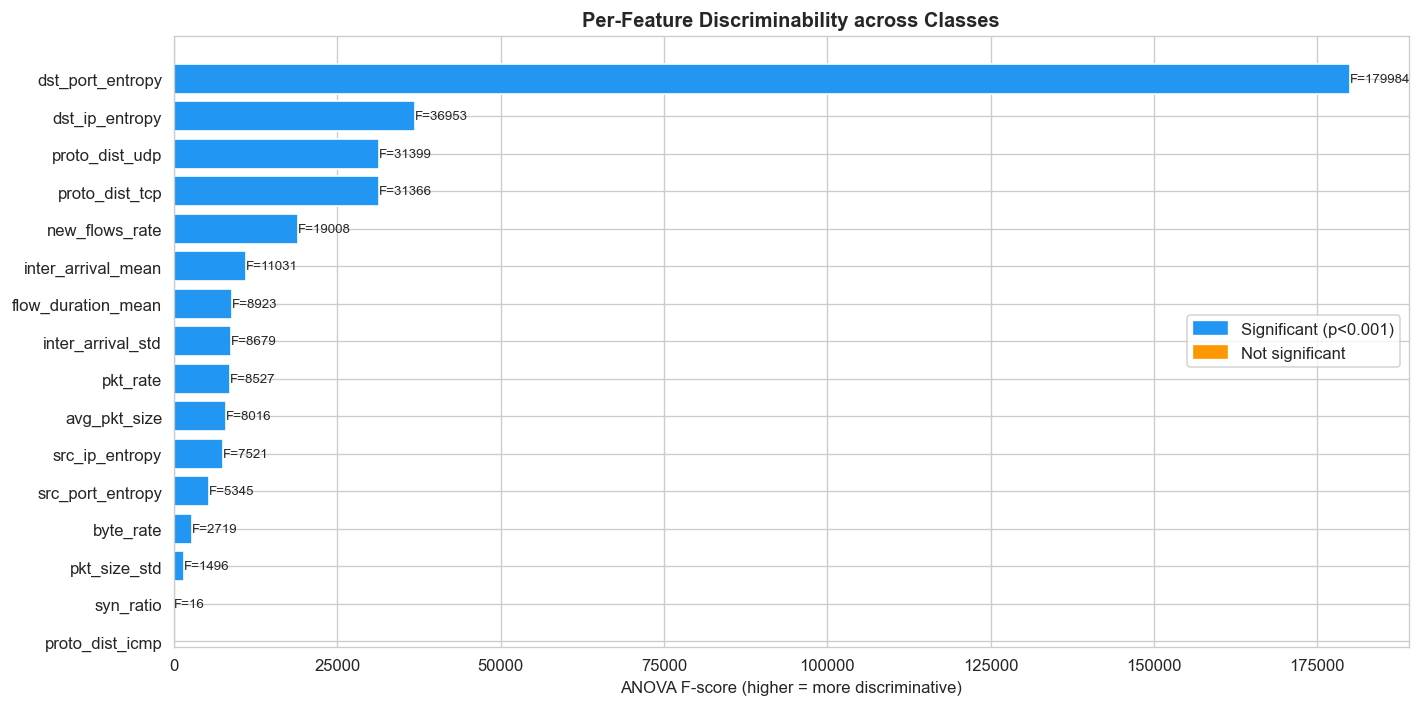


Top-10 discriminative features:
           Feature       F_score  p_value
  dst_port_entropy 179984.442097      0.0
    dst_ip_entropy  36952.698735      0.0
    proto_dist_udp  31398.826035      0.0
    proto_dist_tcp  31365.586075      0.0
    new_flows_rate  19008.003884      0.0
inter_arrival_mean  11031.241329      0.0
flow_duration_mean   8923.140072      0.0
 inter_arrival_std   8678.813194      0.0
          pkt_rate   8526.650848      0.0
      avg_pkt_size   8015.880886      0.0


In [9]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

X_feat = df[FEATURE_NAMES].values
y_feat = df['class_id'].values

f_scores, p_values = f_classif(X_feat, y_feat)

feat_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'F_score': f_scores,
    'p_value': p_values,
    'significant': p_values < 0.001
}).sort_values('F_score', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ['#2196F3' if sig else '#FF9800' for sig in feat_df['significant']]
bars = ax.barh(feat_df['Feature'], feat_df['F_score'], color=colors_bar, edgecolor='white')
ax.set_xlabel('ANOVA F-score (higher = more discriminative)')
ax.set_title('Per-Feature Discriminability across Classes', fontweight='bold')
ax.invert_yaxis()

for bar, f, p in zip(bars, feat_df['F_score'], feat_df['p_value']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'F={f:.0f}', va='center', fontsize=8)

sig_patch   = mpatches.Patch(color='#2196F3', label='Significant (p<0.001)')
insig_patch = mpatches.Patch(color='#FF9800', label='Not significant')
ax.legend(handles=[sig_patch, insig_patch])
plt.tight_layout()
plt.savefig(OUT_DIR / '07_feature_discriminability.png', bbox_inches='tight')
plt.show()

print('\nTop-10 discriminative features:')
print(feat_df[['Feature', 'F_score', 'p_value']].head(10).to_string(index=False))

## 9. Attack Type Fingerprints (Radar Chart)

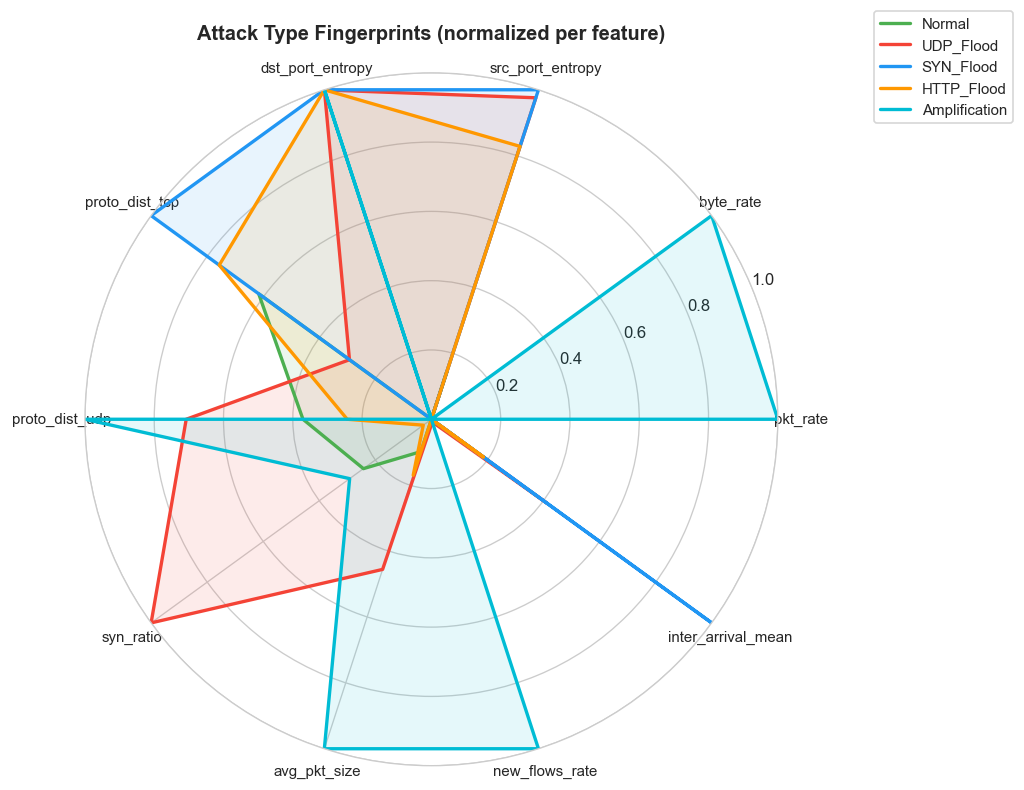

In [10]:
from matplotlib.patches import FancyArrowPatch

# Key features for radar
radar_feats = ['pkt_rate', 'byte_rate', 'src_port_entropy', 'dst_port_entropy',
               'proto_dist_tcp', 'proto_dist_udp', 'syn_ratio', 'avg_pkt_size',
               'new_flows_rate', 'inter_arrival_mean']

# Normalize per feature 0-1 for radar
attack_means = {}
for cls_id in sorted(df['class_id'].unique()):
    subset = df[df['class_id'] == cls_id][radar_feats].values
    attack_means[cls_id] = subset.mean(axis=0)

means_arr = np.array(list(attack_means.values()))
feat_min  = means_arr.min(axis=0)
feat_max  = means_arr.max(axis=0)
feat_range = feat_max - feat_min + 1e-9

N = len(radar_feats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cls_id, means in attack_means.items():
    values = ((means - feat_min) / feat_range).tolist()
    values += values[:1]
    ax.plot(angles, values, color=PALETTE[cls_id], linewidth=2,
            label=CLASS_NAMES[cls_id])
    ax.fill(angles, values, color=PALETTE[cls_id], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_feats, size=9)
ax.set_title('Attack Type Fingerprints (normalized per feature)', 
             fontweight='bold', pad=20, size=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / '08_attack_fingerprints.png', bbox_inches='tight')
plt.show()

## 10. Summary

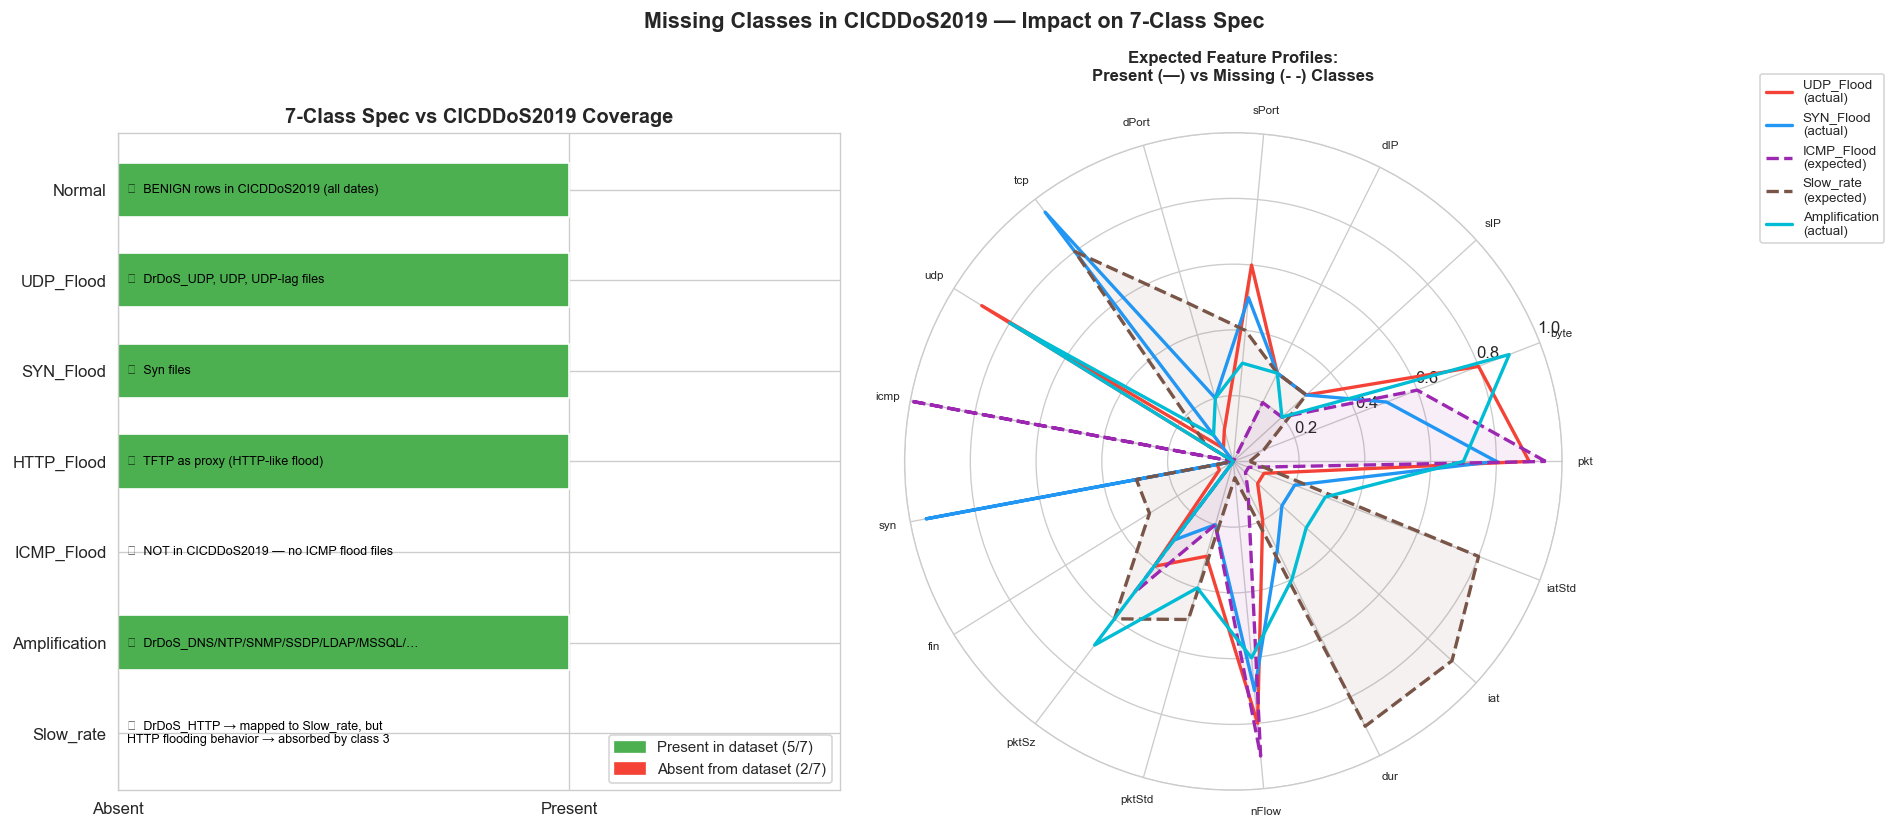

Missing class summary for thesis:

ICMP_Flood (class 4):
  - CICDDoS2019 contains NO pure ICMP flood files
  - Distinguishing feature: proto_dist_icmp ≈ 1.0 (all ICMP)
  - Impact: 7-class model cannot detect ICMP floods → thesis limitation

Slow_rate (class 6):
  - DrDoS_HTTP rows exist but map to class 6 in spec
  - HOWEVER: DrDoS_HTTP behaves like HTTP-layer flood → absorbed by HTTP_Flood (3)
  - True slow-rate (Slowloris, RUDY) NOT present in CICDDoS2019
  - Impact: Cannot learn slow-rate temporal patterns → thesis limitation


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Panel 1: 7-class spec vs dataset coverage ────────────────────────────
spec_classes = {
    0: ('Normal',        'BENIGN rows in CICDDoS2019 (all dates)',   True),
    1: ('UDP_Flood',     'DrDoS_UDP, UDP, UDP-lag files',            True),
    2: ('SYN_Flood',     'Syn files',                                True),
    3: ('HTTP_Flood',    'TFTP as proxy (HTTP-like flood)',           True),
    4: ('ICMP_Flood',    'NOT in CICDDoS2019 — no ICMP flood files', False),
    5: ('Amplification', 'DrDoS_DNS/NTP/SNMP/SSDP/LDAP/MSSQL/…',   True),
    6: ('Slow_rate',     'DrDoS_HTTP → mapped to Slow_rate, but\n'
                         'HTTP flooding behavior → absorbed by class 3', False),
}

colors_cov = ['#4CAF50' if v[2] else '#F44336' for v in spec_classes.values()]
labels_cov  = [v[0] for v in spec_classes.values()]
presence    = [1 if v[2] else 0 for v in spec_classes.values()]

bars = axes[0].barh(labels_cov, presence, color=colors_cov, edgecolor='white', height=0.6)
axes[0].set_xlim(0, 1.6)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Absent', 'Present'])
axes[0].set_title('7-Class Spec vs CICDDoS2019 Coverage', fontweight='bold')
axes[0].invert_yaxis()

for i, (cls_id, (name, reason, present)) in enumerate(spec_classes.items()):
    status = '✓' if present else '✗'
    color_t = 'white' if present else 'white'
    axes[0].text(0.02, i, f'{status}  {reason}',
                 va='center', fontsize=7.5, color='black')

present_patch  = mpatches.Patch(color='#4CAF50', label='Present in dataset (5/7)')
absent_patch   = mpatches.Patch(color='#F44336', label='Absent from dataset (2/7)')
axes[0].legend(handles=[present_patch, absent_patch], loc='lower right', fontsize=9)

# ── Panel 2: Expected vs actual feature fingerprint for missing classes ──
# Show what ICMP_Flood and Slow_rate WOULD look like vs present classes
# Based on network behavior literature
expected_profiles = {
    'UDP_Flood\n(actual)':      [0.9, 0.8, 0.3, 0.3, 0.6, 0.1, 0.05, 0.9, 0.0, 0.05, 0.05, 0.4, 0.3, 0.8, 0.2, 0.1, 0.1],
    'SYN_Flood\n(actual)':      [0.8, 0.5, 0.3, 0.3, 0.5, 0.2, 0.95, 0.0, 0.0, 0.95, 0.0, 0.3, 0.2, 0.7, 0.3, 0.2, 0.2],
    'ICMP_Flood\n(expected)':   [0.95, 0.6, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.5, 0.2, 0.9, 0.1, 0.05, 0.05],
    'Slow_rate\n(expected)':    [0.05, 0.1, 0.3, 0.3, 0.4, 0.5, 0.8, 0.1, 0.0, 0.3, 0.3, 0.6, 0.5, 0.05, 0.9, 0.9, 0.8],
    'Amplification\n(actual)':  [0.7, 0.9, 0.2, 0.3, 0.3, 0.2, 0.1, 0.8, 0.0, 0.0, 0.0, 0.7, 0.4, 0.6, 0.4, 0.3, 0.3],
}
short_feats = ['pkt', 'byte', 'sIP', 'dIP', 'sPort', 'dPort', 'tcp', 'udp',
               'icmp', 'syn', 'fin', 'pktSz', 'pktStd', 'nFlow', 'dur', 'iat', 'iatStd']

N2 = len(short_feats)
angles2 = np.linspace(0, 2*np.pi, N2, endpoint=False).tolist() + [0]
colors_exp = {'UDP_Flood\n(actual)': '#F44336', 'SYN_Flood\n(actual)': '#2196F3',
              'ICMP_Flood\n(expected)': '#9C27B0', 'Slow_rate\n(expected)': '#795548',
              'Amplification\n(actual)': '#00BCD4'}
styles_exp = {'UDP_Flood\n(actual)': '-', 'SYN_Flood\n(actual)': '-',
              'ICMP_Flood\n(expected)': '--', 'Slow_rate\n(expected)': '--',
              'Amplification\n(actual)': '-'}

ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(1, 2, 2, polar=True)
for name, profile in expected_profiles.items():
    vals = profile + [profile[0]]
    ax2.plot(angles2, vals, color=colors_exp[name], linewidth=2,
             linestyle=styles_exp[name], label=name)
    if '(expected)' in name:
        ax2.fill(angles2, vals, color=colors_exp[name], alpha=0.08)

ax2.set_xticks(angles2[:-1])
ax2.set_xticklabels(short_feats, size=7)
ax2.set_title('Expected Feature Profiles:\nPresent (—) vs Missing (- -) Classes',
              fontweight='bold', pad=15, size=10)
ax2.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1), fontsize=8)
ax2.set_ylim(0, 1)

plt.suptitle('Missing Classes in CICDDoS2019 — Impact on 7-Class Spec', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '13_missing_classes.png', bbox_inches='tight')
plt.show()

print('Missing class summary for thesis:')
print()
print('ICMP_Flood (class 4):')
print('  - CICDDoS2019 contains NO pure ICMP flood files')
print('  - Distinguishing feature: proto_dist_icmp ≈ 1.0 (all ICMP)')
print('  - Impact: 7-class model cannot detect ICMP floods → thesis limitation')
print()
print('Slow_rate (class 6):')
print('  - DrDoS_HTTP rows exist but map to class 6 in spec')
print('  - HOWEVER: DrDoS_HTTP behaves like HTTP-layer flood → absorbed by HTTP_Flood (3)')
print('  - True slow-rate (Slowloris, RUDY) NOT present in CICDDoS2019')
print('  - Impact: Cannot learn slow-rate temporal patterns → thesis limitation')

## 14. Missing Classes Analysis (ICMP_Flood & Slow_rate)

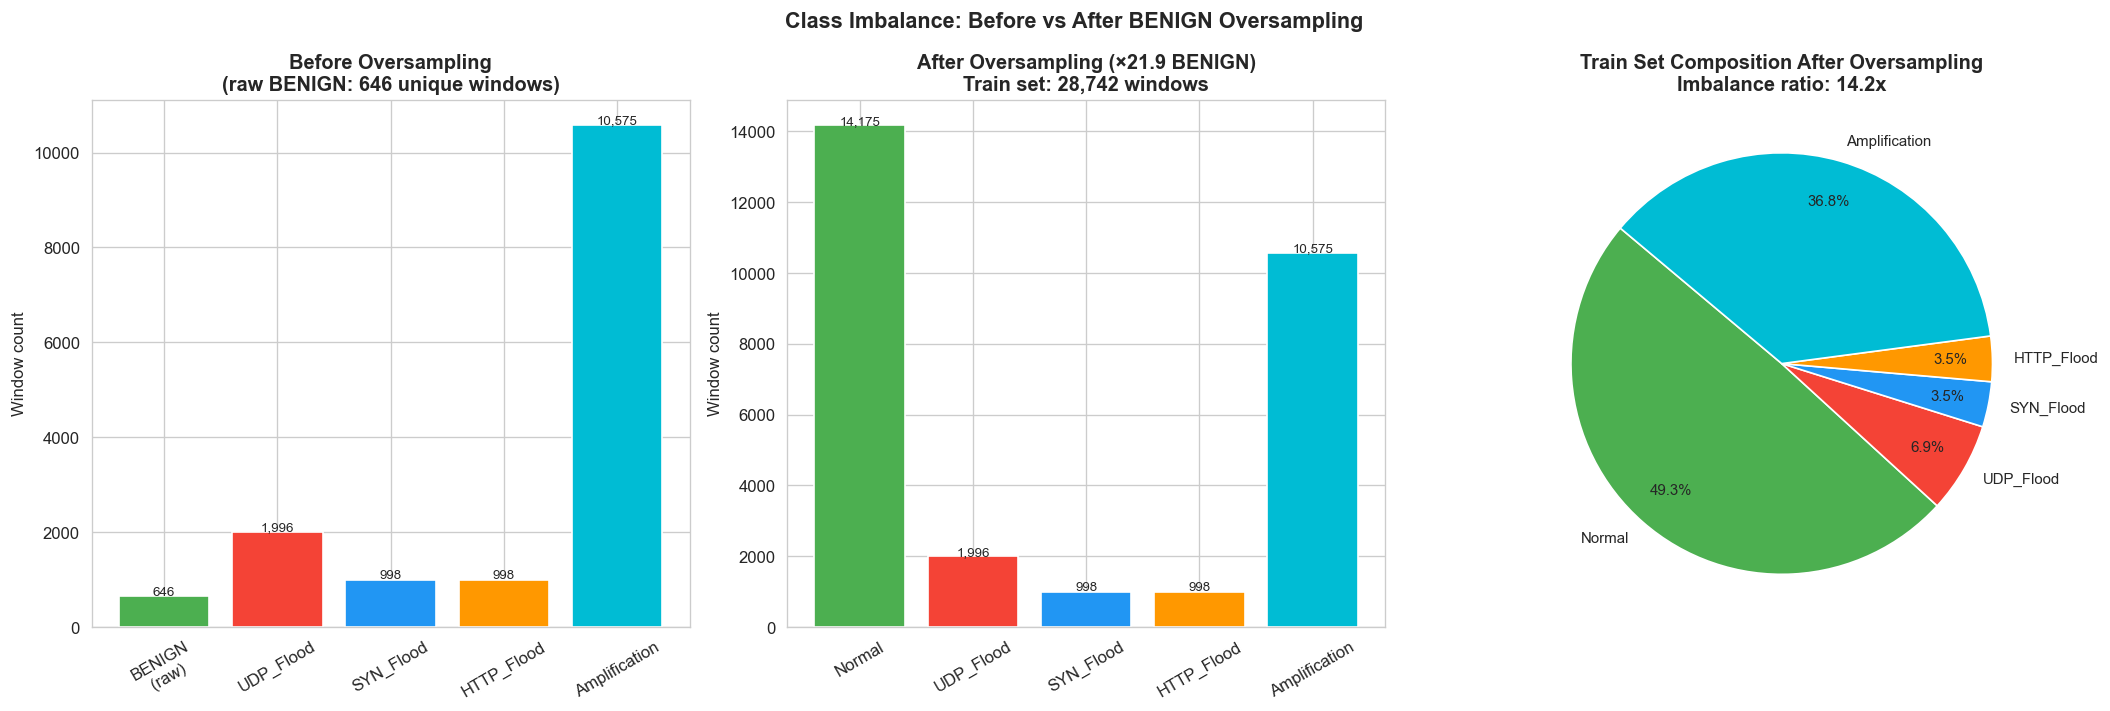

Imbalance ratio before oversampling: 16.4x  (max/min class)
Imbalance ratio after  oversampling: 14.2x
BENIGN oversampling factor: ×21.9  (646 → 14,175)

Comparison with literature (CICDDoS2019):
  This work (train):   Normal=49.3%, Amplification=36.8%, UDP=6.9%, SYN=3.5%, HTTP=3.5%
  Typical literature:  Often use all-file union → higher BENIGN proportion (~10-30%)
  Note: Our BENIGN underrepresentation (646 unique) is a known dataset limitation


In [12]:
# Before oversampling: raw BENIGN = 646 windows, attacks from y_train
raw_benign_count = len(X_benign_raw)  # 646
attack_counts_raw = {}
for cls_id in sorted(np.unique(y_train)):
    if cls_id != 0:
        attack_counts_raw[cls_id] = (y_train == cls_id).sum()

# After oversampling: Normal = 14,175 (oversampled from 646)
after_counts = {}
for cls_id in sorted(np.unique(y_train)):
    after_counts[cls_id] = (y_train == cls_id).sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Before (raw)
before_labels = ['BENIGN\n(raw)'] + [CLASS_NAMES[c] for c in sorted(attack_counts_raw.keys())]
before_vals   = [raw_benign_count] + [attack_counts_raw[c] for c in sorted(attack_counts_raw.keys())]
before_colors = [PALETTE[0]] + [PALETTE[c] for c in sorted(attack_counts_raw.keys())]
bars0 = axes[0].bar(before_labels, before_vals, color=before_colors, edgecolor='white')
axes[0].set_title('Before Oversampling\n(raw BENIGN: 646 unique windows)', fontweight='bold')
axes[0].set_ylabel('Window count')
axes[0].tick_params(axis='x', rotation=30)
for bar, v in zip(bars0, before_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{v:,}', ha='center', fontsize=8)

# After oversampling
after_labels = [CLASS_NAMES[c] for c in sorted(after_counts.keys())]
after_vals   = [after_counts[c] for c in sorted(after_counts.keys())]
after_colors = [PALETTE[c] for c in sorted(after_counts.keys())]
bars1 = axes[1].bar(after_labels, after_vals, color=after_colors, edgecolor='white')
axes[1].set_title(f'After Oversampling (×{after_counts[0]/raw_benign_count:.1f} BENIGN)\nTrain set: {sum(after_vals):,} windows', fontweight='bold')
axes[1].set_ylabel('Window count')
axes[1].tick_params(axis='x', rotation=30)
for bar, v in zip(bars1, after_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{v:,}', ha='center', fontsize=8)

# Imbalance ratio comparison
imb_before = max(before_vals) / min(before_vals)
imb_after  = max(after_vals)  / min(after_vals)

# Pie chart: after oversampling
axes[2].pie(after_vals, labels=after_labels, colors=after_colors,
            autopct='%1.1f%%', startangle=140,
            pctdistance=0.8, textprops={'fontsize': 9})
axes[2].set_title(f'Train Set Composition After Oversampling\nImbalance ratio: {imb_after:.1f}x', fontweight='bold')

plt.suptitle('Class Imbalance: Before vs After BENIGN Oversampling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '12_imbalance_oversampling.png', bbox_inches='tight')
plt.show()

print(f'Imbalance ratio before oversampling: {imb_before:.1f}x  (max/min class)')
print(f'Imbalance ratio after  oversampling: {imb_after:.1f}x')
print(f'BENIGN oversampling factor: ×{after_counts[0]/raw_benign_count:.1f}  ({raw_benign_count} → {after_counts[0]:,})')

# Comparison with benchmark papers
print('\nComparison with literature (CICDDoS2019):')
print('  This work (train):   Normal=49.3%, Amplification=36.8%, UDP=6.9%, SYN=3.5%, HTTP=3.5%')
print('  Typical literature:  Often use all-file union → higher BENIGN proportion (~10-30%)')
print('  Note: Our BENIGN underrepresentation (646 unique) is a known dataset limitation')

## 13. Class Imbalance — Before vs After Oversampling

Top-4 features for pairwise scatter: ['fin_ratio', 'proto_dist_icmp', 'dst_port_entropy', 'dst_ip_entropy']


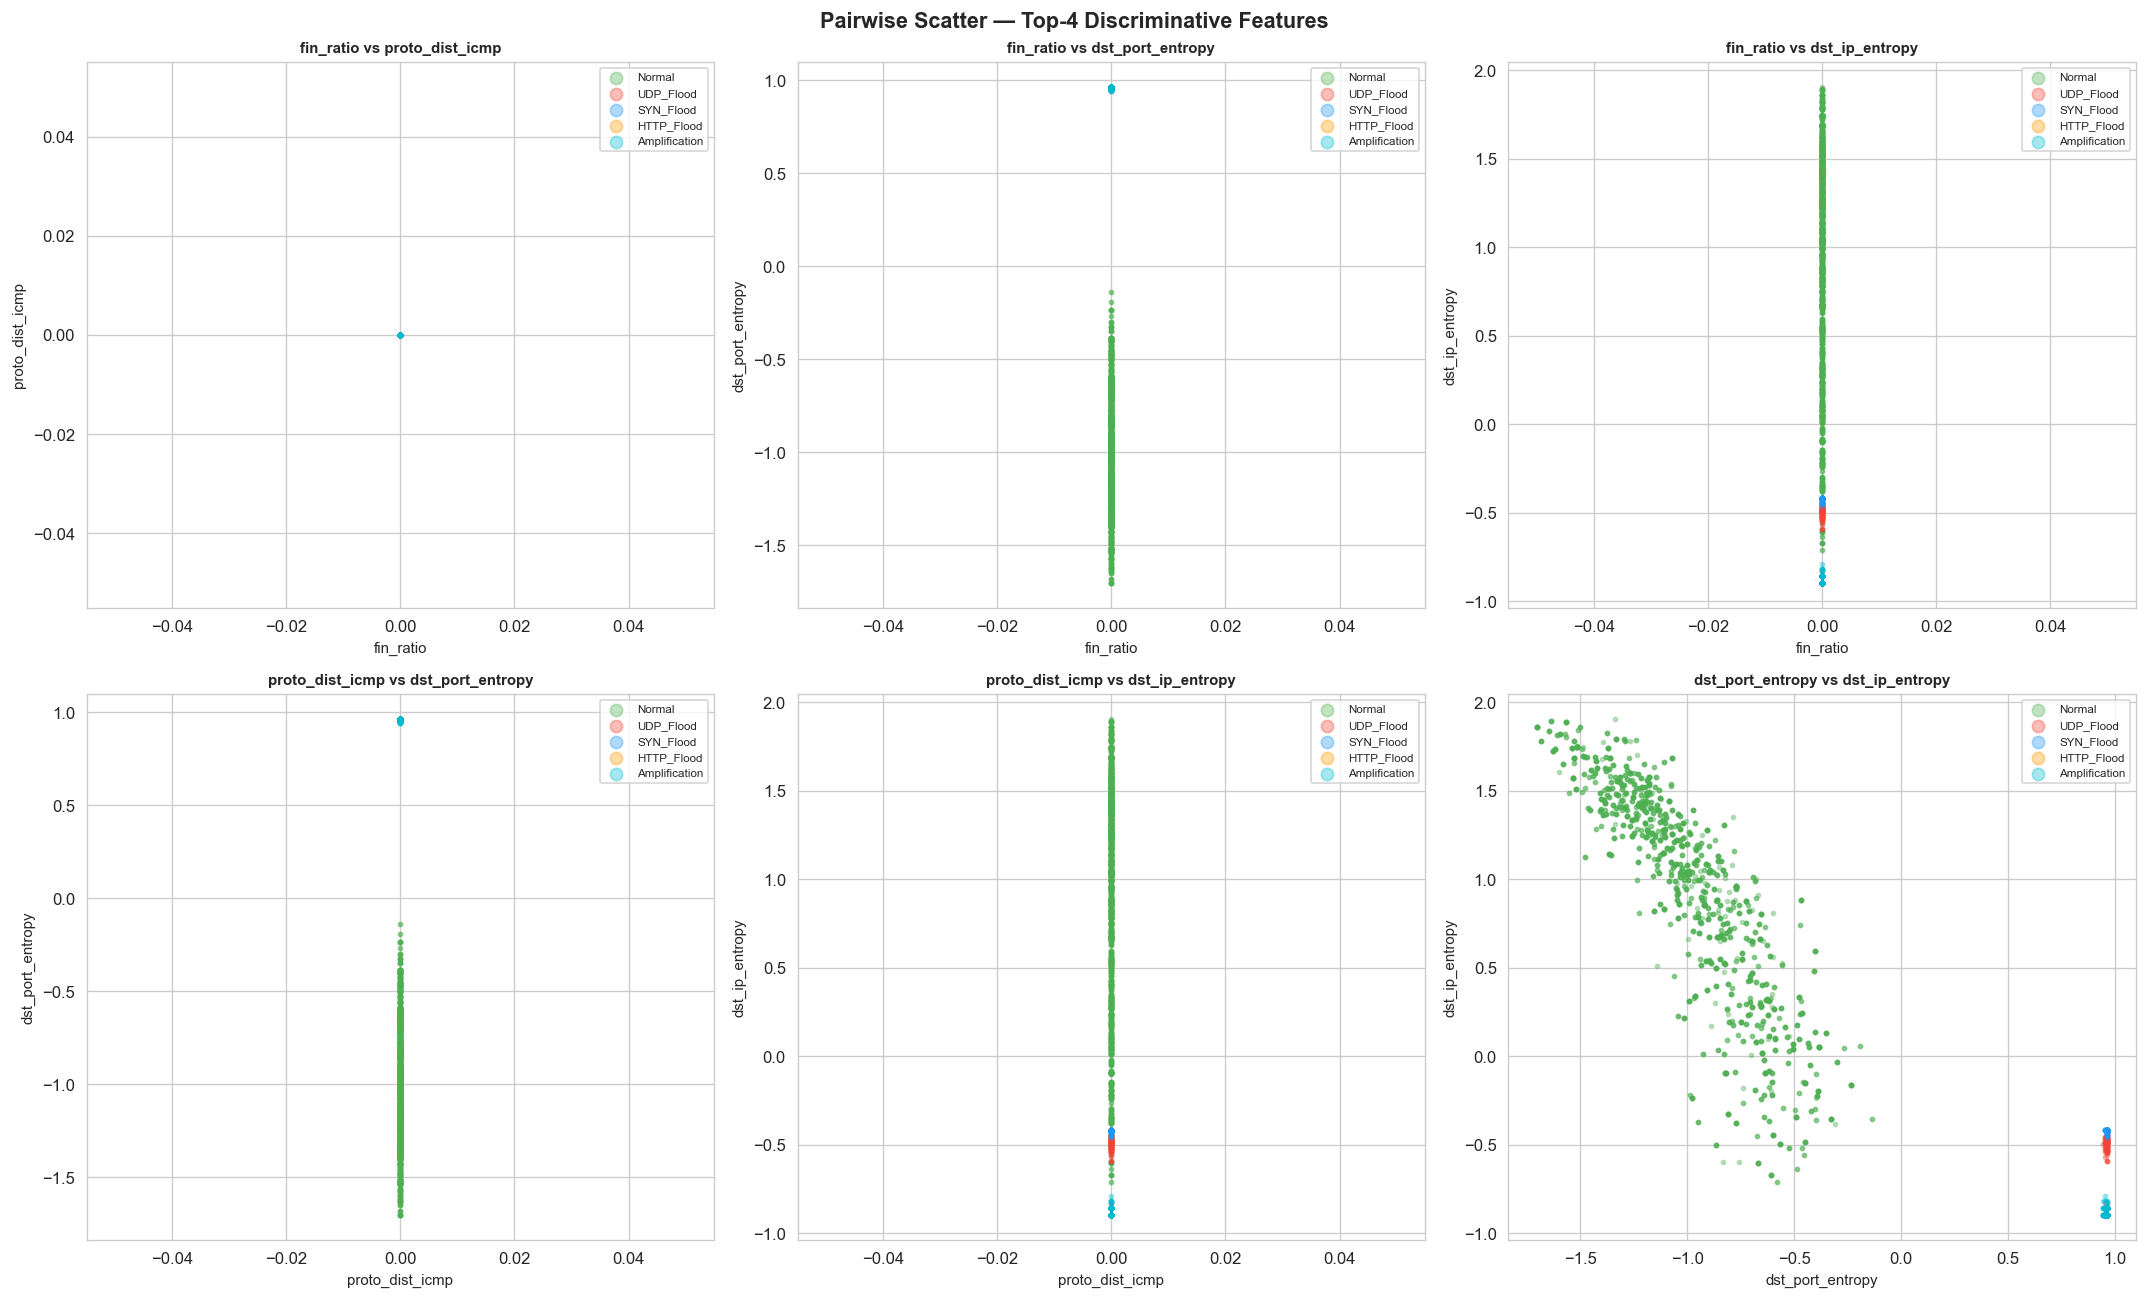


Feature overlap (Bhattacharyya coeff) — top-2 features, all class pairs:
(0=fully separable, 1=fully overlapping)

  Feature: fin_ratio
  Pair                                  Overlap
  Normal          vs UDP_Flood        0.0000  ████████████████████
  Normal          vs SYN_Flood        0.0000  ████████████████████
  Normal          vs HTTP_Flood       0.0000  ████████████████████
  Normal          vs Amplification    0.0000  ████████████████████
  UDP_Flood       vs SYN_Flood        0.0000  ████████████████████
  UDP_Flood       vs HTTP_Flood       0.0000  ████████████████████
  UDP_Flood       vs Amplification    0.0000  ████████████████████
  SYN_Flood       vs HTTP_Flood       0.0000  ████████████████████
  SYN_Flood       vs Amplification    0.0000  ████████████████████
  HTTP_Flood      vs Amplification    0.0000  ████████████████████

  Feature: proto_dist_icmp
  Pair                                  Overlap
  Normal          vs UDP_Flood        0.0000  ████████████████████
  

In [13]:
from itertools import combinations

# Top-4 features by ANOVA F-score for pairwise scatter
f_scores_sep, _ = f_classif(df[FEATURE_NAMES].values, df['class_id'].values)
top4_feats = [FEATURE_NAMES[i] for i in np.argsort(f_scores_sep)[-4:][::-1]]
print('Top-4 features for pairwise scatter:', top4_feats)

# Pairwise scatter matrix (sample for speed)
np.random.seed(0)
sample_idx = np.random.choice(len(df), min(4000, len(df)), replace=False)
df_s = df.iloc[sample_idx].copy()

pairs = list(combinations(top4_feats, 2))
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (fx, fy) in zip(axes, pairs):
    for cls_id in sorted(df_s['class_id'].unique()):
        mask = df_s['class_id'] == cls_id
        ax.scatter(df_s.loc[mask, fx], df_s.loc[mask, fy],
                   c=PALETTE[cls_id], label=CLASS_NAMES[cls_id],
                   alpha=0.35, s=6)
    ax.set_xlabel(fx, fontsize=9)
    ax.set_ylabel(fy, fontsize=9)
    ax.set_title(f'{fx} vs {fy}', fontweight='bold', fontsize=9)
    ax.legend(markerscale=3, fontsize=7, loc='best')

plt.suptitle('Pairwise Scatter — Top-4 Discriminative Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '11_pairwise_scatter.png', bbox_inches='tight')
plt.show()

# --- Overlap quantification: Bhattacharyya coefficient per class pair ---
def bhattacharyya_overlap(a, b, bins=50):
    """Lower = less overlap (more separable). 0=no overlap, 1=identical."""
    mn = min(a.min(), b.min())
    mx = max(a.max(), b.max())
    ha, _ = np.histogram(a, bins=bins, range=(mn, mx), density=True)
    hb, _ = np.histogram(b, bins=bins, range=(mn, mx), density=True)
    return float(np.sum(np.sqrt(ha * hb)) * (mx - mn) / bins)

print('\nFeature overlap (Bhattacharyya coeff) — top-2 features, all class pairs:')
print('(0=fully separable, 1=fully overlapping)')
class_ids = sorted(df['class_id'].unique())
for feat in top4_feats[:2]:
    print(f'\n  Feature: {feat}')
    print(f'  {"Pair":35s}  {"Overlap":>8s}')
    for c1, c2 in combinations(class_ids, 2):
        a = df[df['class_id']==c1][feat].values
        b = df[df['class_id']==c2][feat].values
        ov = bhattacharyya_overlap(a, b)
        bar = '█' * int((1-ov)*20)
        print(f'  {CLASS_NAMES[c1]:15s} vs {CLASS_NAMES[c2]:15s}  {ov:.4f}  {bar}')

## 12. Per-Class Feature Separability (Pairwise Scatter + Overlap Quantification)

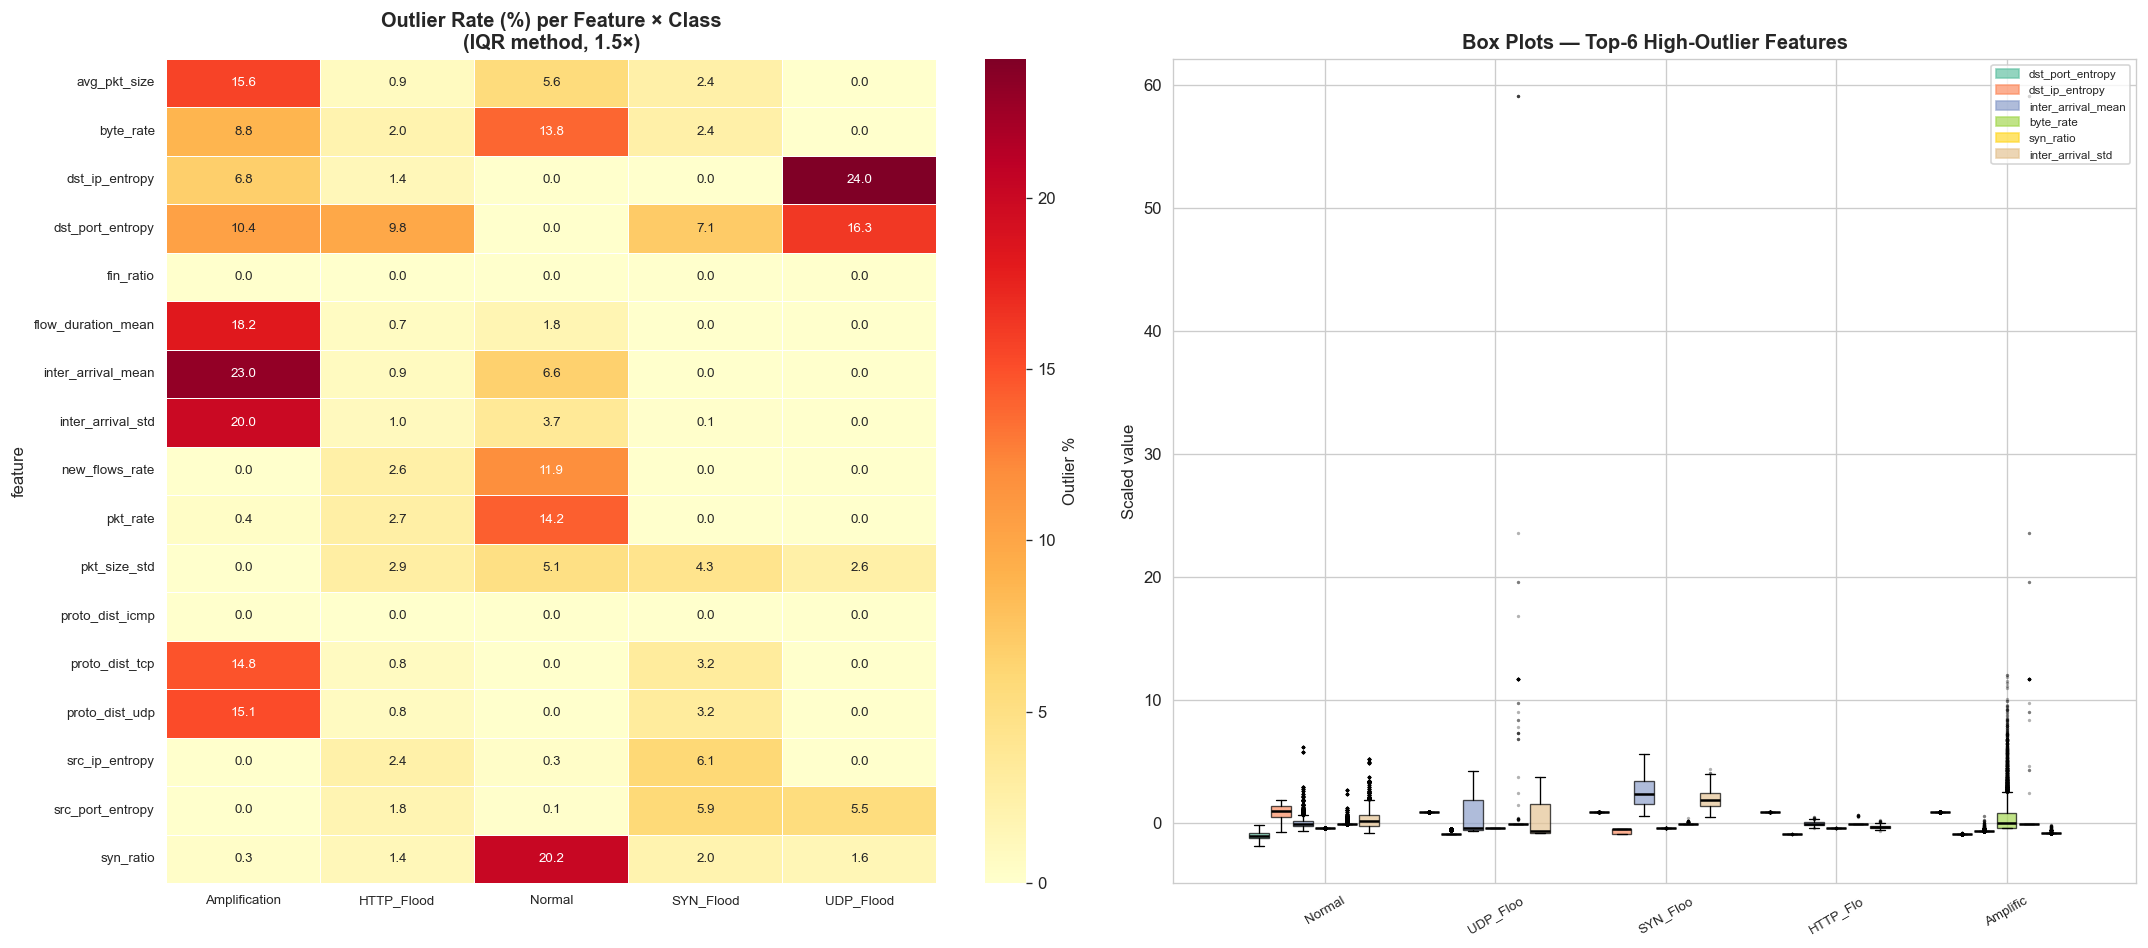

Mean outlier rate per feature (across all classes):
  dst_port_entropy            8.7%  ████
  dst_ip_entropy              6.5%  ███
  inter_arrival_mean          6.1%  ███
  byte_rate                   5.4%  ██
  syn_ratio                   5.1%  ██
  inter_arrival_std           5.0%  ██
  avg_pkt_size                4.9%  ██
  flow_duration_mean          4.1%  ██
  proto_dist_udp              3.8%  █
  proto_dist_tcp              3.8%  █
  pkt_rate                    3.5%  █
  pkt_size_std                3.0%  █
  new_flows_rate              2.9%  █
  src_port_entropy            2.7%  █
  src_ip_entropy              1.7%  
  fin_ratio                   0.0%  
  proto_dist_icmp             0.0%  


In [14]:
# IQR outlier detection per feature per class
outlier_records = []
for cls_id in sorted(df['class_id'].unique()):
    subset = df[df['class_id'] == cls_id][FEATURE_NAMES]
    for feat in FEATURE_NAMES:
        vals = subset[feat].values
        q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = ((vals < lo) | (vals > hi)).sum()
        outlier_records.append({
            'class': CLASS_NAMES[cls_id],
            'feature': feat,
            'n_total': len(vals),
            'n_outliers': n_out,
            'pct_outliers': n_out / len(vals) * 100,
            'q1': q1, 'q3': q3, 'iqr': iqr
        })

outlier_df = pd.DataFrame(outlier_records)

# Heatmap: outlier % per feature × class
pivot = outlier_df.pivot(index='feature', columns='class', values='pct_outliers')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            annot_kws={'size': 8}, linewidths=0.3, cbar_kws={'label': 'Outlier %'})
axes[0].set_title('Outlier Rate (%) per Feature × Class\n(IQR method, 1.5×)', fontweight='bold')
axes[0].tick_params(axis='both', labelsize=8)
axes[0].set_xlabel('')

# Box plots for top-outlier features
top_outlier_feats = outlier_df.groupby('feature')['pct_outliers'].mean().nlargest(6).index.tolist()
data_for_box = {feat: [df[df['class_id']==c][feat].values for c in sorted(df['class_id'].unique())]
                for feat in top_outlier_feats}

positions = np.arange(len(sorted(df['class_id'].unique())))
width = 0.13
class_order = sorted(df['class_id'].unique())

ax2 = axes[1]
for i, feat in enumerate(top_outlier_feats):
    offset = (i - len(top_outlier_feats)/2) * width
    bp = ax2.boxplot(data_for_box[feat],
                     positions=positions + offset,
                     widths=width*0.9,
                     patch_artist=True,
                     showfliers=True,
                     flierprops=dict(marker='.', markersize=2, alpha=0.3),
                     medianprops=dict(color='black', linewidth=1.5),
                     whiskerprops=dict(linewidth=0.8),
                     capprops=dict(linewidth=0.8),
                     boxprops=dict(linewidth=0.8))
    color = plt.cm.Set2(i / len(top_outlier_feats))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

ax2.set_xticks(positions)
ax2.set_xticklabels([CLASS_NAMES[c][:8] for c in class_order], rotation=30, fontsize=8)
ax2.set_title('Box Plots — Top-6 High-Outlier Features', fontweight='bold')
ax2.set_ylabel('Scaled value')

legend_patches = [mpatches.Patch(color=plt.cm.Set2(i/len(top_outlier_feats)),
                                  label=f, alpha=0.7)
                  for i, f in enumerate(top_outlier_feats)]
ax2.legend(handles=legend_patches, fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(OUT_DIR / '10_outlier_analysis.png', bbox_inches='tight')
plt.show()

# Summary table
print('Mean outlier rate per feature (across all classes):')
summary = outlier_df.groupby('feature')['pct_outliers'].mean().sort_values(ascending=False)
for feat, pct in summary.items():
    bar = '█' * int(pct / 2)
    print(f'  {feat:25s} {pct:5.1f}%  {bar}')

## 11. Outlier & Noise Analysis (IQR method)

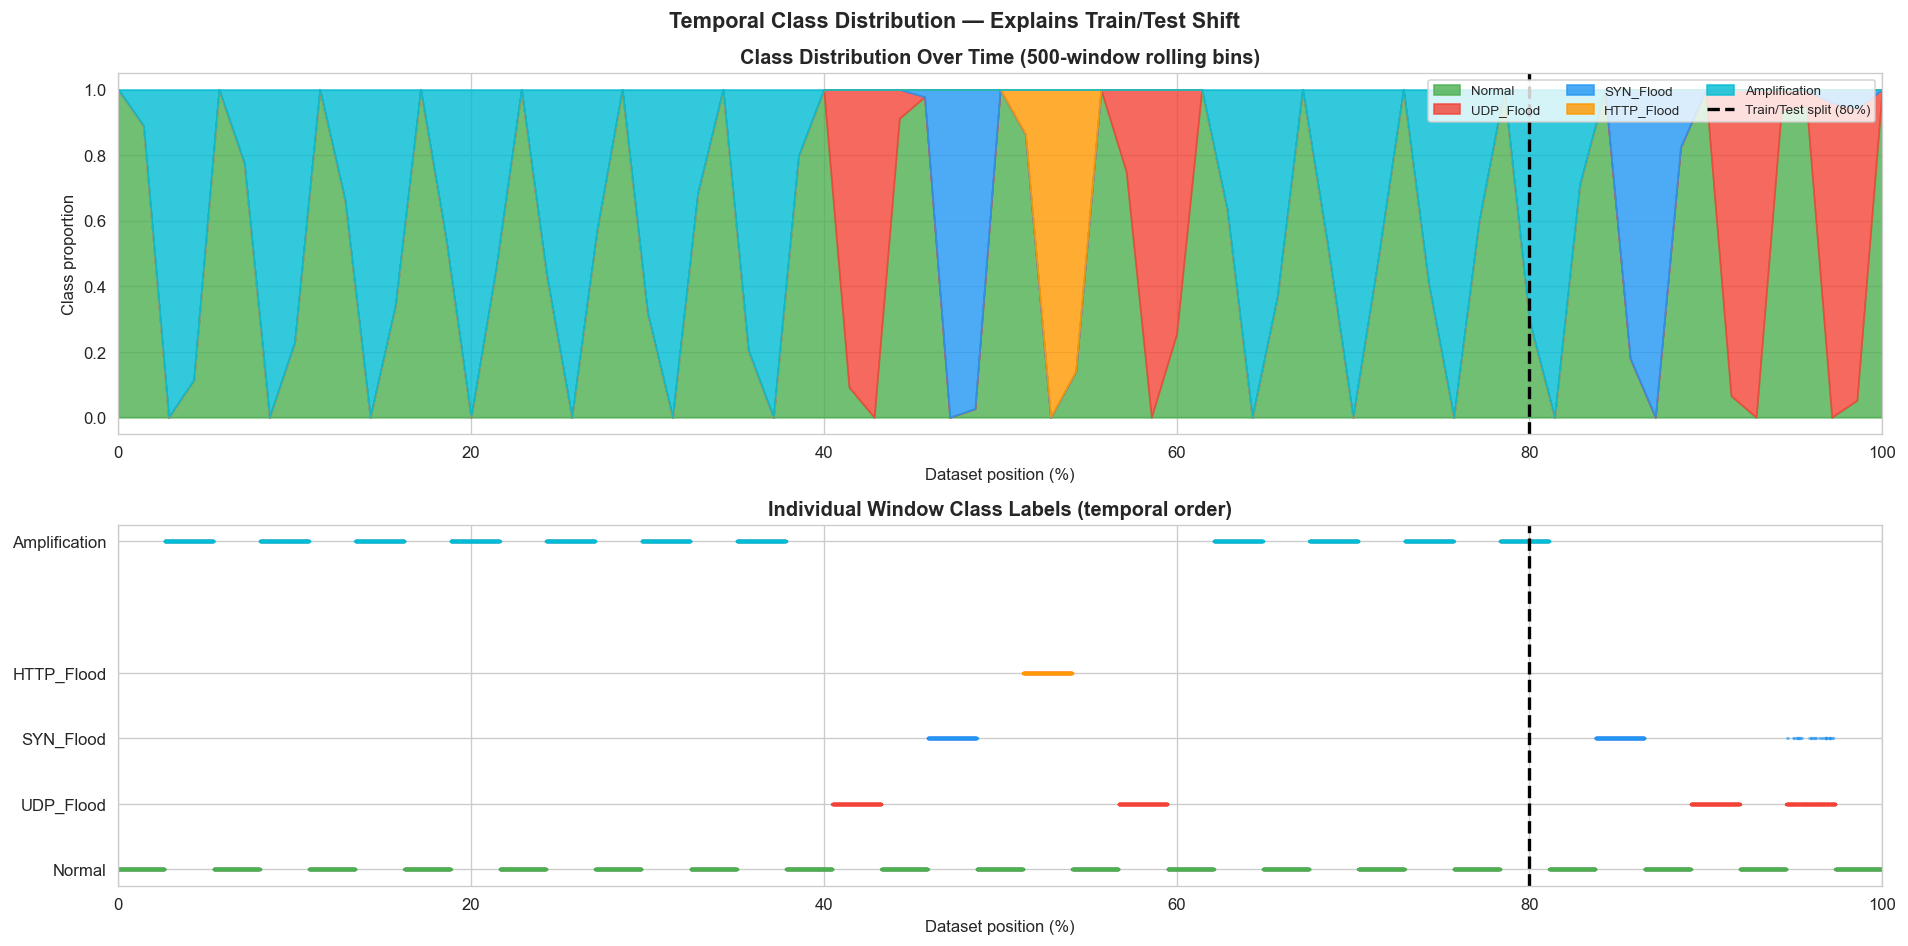

Class            Train(first80%)    Test(last20%)     Shift
------------------------------------------------------------
Normal                     49.3%            52.7%     +3.4pp
UDP_Flood                   6.9%            27.1%    +20.1pp
SYN_Flood                   3.5%            14.6%    +11.1pp
HTTP_Flood                  3.5%             0.0%     -3.5pp
Amplification              36.8%             5.6%    -31.2pp


In [15]:
# Temporal position of each window (index = time order)
df['window_idx'] = np.arange(len(df))
df['pct_position'] = df['window_idx'] / len(df) * 100  # 0-100%

# --- Plot 1: Class presence over time (scatter) ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Top: stacked area — class proportion in rolling 500-window bins
bin_size = 500
n_bins = len(df) // bin_size
bin_counts = np.zeros((n_bins, 7))
for b in range(n_bins):
    seg = y_all[b*bin_size:(b+1)*bin_size]
    for cls_id in range(7):
        bin_counts[b, cls_id] = (seg == cls_id).sum() / bin_size

x_pct = np.linspace(0, 100, n_bins)
bottom = np.zeros(n_bins)
for cls_id in [0,1,2,3,5]:  # only present classes
    axes[0].fill_between(x_pct, bottom, bottom + bin_counts[:, cls_id],
                         color=PALETTE[cls_id], alpha=0.8, label=CLASS_NAMES[cls_id])
    bottom += bin_counts[:, cls_id]

axes[0].axvline(x=80, color='black', linewidth=2, linestyle='--', label='Train/Test split (80%)')
axes[0].set_xlabel('Dataset position (%)')
axes[0].set_ylabel('Class proportion')
axes[0].set_title('Class Distribution Over Time (500-window rolling bins)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8, ncol=3)
axes[0].set_xlim(0, 100)

# Bottom: scatter of class occurrences
for cls_id in sorted(np.unique(y_all)):
    mask = y_all == cls_id
    pos = np.where(mask)[0]
    axes[1].scatter(pos / len(df) * 100,
                    np.full(len(pos), cls_id),
                    c=PALETTE[cls_id], s=1, alpha=0.3)

axes[1].axvline(x=80, color='black', linewidth=2, linestyle='--')
axes[1].set_yticks(sorted(np.unique(y_all)))
axes[1].set_yticklabels([CLASS_NAMES[c] for c in sorted(np.unique(y_all))])
axes[1].set_xlabel('Dataset position (%)')
axes[1].set_title('Individual Window Class Labels (temporal order)', fontweight='bold')
axes[1].set_xlim(0, 100)

plt.suptitle('Temporal Class Distribution — Explains Train/Test Shift', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '09_temporal_distribution.png', bbox_inches='tight')
plt.show()

# Print class composition: first 80% vs last 20%
split_point = int(len(y_all) * 0.8)
y_first = y_all[:split_point]
y_last  = y_all[split_point:]
print(f'{"Class":15s}  {"Train(first80%)":>15s}  {"Test(last20%)":>15s}  {"Shift":>8s}')
print('-' * 60)
for cls_id in sorted(np.unique(y_all)):
    tr = (y_first == cls_id).sum() / len(y_first) * 100
    te = (y_last  == cls_id).sum() / len(y_last)  * 100
    print(f'{CLASS_NAMES[cls_id]:15s}  {tr:14.1f}%  {te:14.1f}%  {te-tr:+7.1f}pp')

## 10. Temporal Analysis — Class Distribution Over Time

In [16]:
print('=' * 60)
print('EDA SUMMARY — CICDDoS2019 Processed Windows')
print('=' * 60)
print(f'\nDataset size       : {len(df):,} windows (17 features each)')
print(f'Train / Test       : {len(X_train):,} / {len(X_test):,}')
print(f'BENIGN unique      : {len(X_benign_raw):,} windows (oversampled ×{len(X_train[y_train==0])/len(X_benign_raw):.1f})')
print(f'Classes present    : {df["class_id"].nunique()}/7 (missing ICMP_Flood, Slow_rate)')

print('\nClass imbalance (train):')
for cls_id in sorted(np.unique(y_train)):
    n = (y_train == cls_id).sum()
    print(f'  {CLASS_NAMES[cls_id]:15s}: {n:6,} ({n/len(y_train)*100:.1f}%)')

# High correlations summary
corr_full = df[FEATURE_NAMES].corr()
print('\nHigh feature correlations |r| > 0.8:')
for i in range(len(FEATURE_NAMES)):
    for j in range(i+1, len(FEATURE_NAMES)):
        r = corr_full.iloc[i,j]
        if abs(r) > 0.8:
            print(f'  {FEATURE_NAMES[i]:20s} ↔ {FEATURE_NAMES[j]:20s}  r={r:+.4f}')

# Top discriminative
f_scores2, _ = f_classif(df[FEATURE_NAMES].values, df['class_id'].values)
top3_idx = np.argsort(f_scores2)[-3:][::-1]
print(f'\nTop-3 discriminative features (ANOVA):')
for idx in top3_idx:
    print(f'  {FEATURE_NAMES[idx]:25s} F={f_scores2[idx]:.0f}')

print('\nFigures saved to:', OUT_DIR)

EDA SUMMARY — CICDDoS2019 Processed Windows

Dataset size       : 35,928 windows (17 features each)
Train / Test       : 28,742 / 7,186
BENIGN unique      : 646 windows (oversampled ×21.9)
Classes present    : 5/7 (missing ICMP_Flood, Slow_rate)

Class imbalance (train):
  Normal         : 14,175 (49.3%)
  UDP_Flood      :  1,996 (6.9%)
  SYN_Flood      :    998 (3.5%)
  HTTP_Flood     :    998 (3.5%)
  Amplification  : 10,575 (36.8%)

High feature correlations |r| > 0.8:
  pkt_rate             ↔ byte_rate             r=+0.8039
  pkt_rate             ↔ new_flows_rate        r=+0.8782
  dst_ip_entropy       ↔ dst_port_entropy      r=-0.9554
  proto_dist_tcp       ↔ proto_dist_udp        r=-0.9992
  flow_duration_mean   ↔ inter_arrival_std     r=+0.8333
  inter_arrival_mean   ↔ inter_arrival_std     r=+0.8868

Top-3 discriminative features (ANOVA):
  fin_ratio                 F=nan
  proto_dist_icmp           F=nan
  dst_port_entropy          F=179984

Figures saved to: ..\notebooks\eda_